ขั้นตอนวิเคราะห์และสร้างภาพ รับ CSV ที่ผ่านการ clean แล้วมาวาดกราฟ 6 ชุดและสร้าง Heatmap แผนที่

#ดาวน์โหลดฟอนต์ Sarabun จาก Google Fonts เพื่อให้กราฟ matplotlib แสดงภาษาไทยได้ถูกต้อง

In [119]:
# ===== SETUP =====
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import os

# ฟอนต์ภาษาไทย
!wget -q "https://github.com/google/fonts/raw/main/ofl/sarabun/Sarabun-Regular.ttf" \
     -O /tmp/Sarabun-Regular.ttf
fm.fontManager.addfont('/tmp/Sarabun-Regular.ttf')
prop = fm.FontProperties(fname='/tmp/Sarabun-Regular.ttf')
plt.rcParams['font.family'] = prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

# Path
OUTPUT_DIR = '/content/drive/MyDrive/term4/IS/output'
VIZ_DIR    = OUTPUT_DIR + '/clean/'
GRAPH_DIR  = '/content/drive/MyDrive/term4/IS/graphs/'
os.makedirs(GRAPH_DIR, exist_ok=True)

print("Setup เสร็จแล้ว พร้อมใช้งาน")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup เสร็จแล้ว พร้อมใช้งาน


In [120]:
import pandas as pd
df_cluster_base = pd.read_csv(OUTPUT_DIR + '/clean/ccib_cluster_base.csv', encoding='utf-8-sig')
print(df_cluster_base['ประเภทคดี'].value_counts())

ประเภทคดี
15.คดีอาชญากรรมทางเทคโนโลยีลักษณะอื่นๆ                                                           359824
1.หลอกลวงซื้อขายสินค้าหรือบริการ ที่ไม่มีลักษณะเป็นขบวนการ                                        61737
5.หลอกลวงให้กู้เงินอันมีลักษณะฉ้อโกง กรรโชก หรือรีดเอาทรัพย์                                      17904
6.หลอกลวงให้โอนเงินเพื่อทำงานหารายได้พิเศษ                                                        17337
13.หลอกลวงซื้อขายสินค้าหรือบริการ ที่มีลักษณะเป็นขบวนการ                                          15525
11.หลอกลวงให้ลงทุนผ่านระบบคอมพิวเตอร์                                                             10777
7.ข่มขู่ทางโทรศัพท์ให้เกิดความกลัวแล้วหลอกให้โอนเงิน                                               9289
4.หลอกลวงให้โอนเงินเพื่อรับรางวัลหรือวัตถุประสงค์อื่นๆ                                             8970
8.หลอกลวงให้ติดตั้งโปรแกรมควบคุมระบบในเครื่องโทรศัพท์                                              8893
2.หลอกลวงเป็นบุคคลอื่นเพื่อยืมเงิน                    

#Phase 3 EDA

#3.1 โหลดข้อมูลและเตรียม df_base

In [178]:
# ── Phase 3: EDA ─────────────────────────────────────────
df_base = pd.read_parquet(OUTPUT_DIR + '/clean/ccib_main_clean.parquet')

# สำหรับวิเคราะห์หลัก (Missing, Outlier, Feature Eng.)
df_online = df_base[
    df_base['source_category'] == 'สถิติจำนวนคดีออนไลน์'
].copy()

# สำหรับกราฟมูลค่าความเสียหายใน EDA เท่านั้น  ← เพิ่มตรงนี้
df_damage = df_base[
    df_base['source_category'].str.contains('มูลค่าความเสียหาย')
].copy()

# ลบเลขนำหน้าประเภทคดี
df_online['ประเภทคดี'] = (df_online['ประเภทคดี']
                          .str.replace(r'^\d+\.', '', regex=True)
                          .str.strip())
df_damage['ประเภทคดี'] = (df_damage['ประเภทคดี']
                          .str.replace(r'^\d+\.', '', regex=True)
                          .str.strip())

print(f"df_online  : {len(df_online):,} แถว")
print(f"df_damage  : {len(df_damage):,} แถว")

df_online  : 529,481 แถว
df_damage  : 1,427 แถว


#3.2 Missing Value

In [160]:
import pandas as pd

# Re-load the original ccib_main_clean.csv for this check
# as the current df_base does not have 'source_category'
df_temp = pd.read_csv(OUTPUT_DIR + '/clean/ccib_main_clean.csv', encoding='utf-8-sig')

# เช็คคอลัมน์ที่มีข้อมูลจริงแยกตาม source_category
for category in df_temp['source_category'].unique():
    df_cat = df_temp[df_temp['source_category'] == category]

    # หาคอลัมน์ที่มีข้อมูลจริง (ไม่ใช่ NaN ทั้งหมด)
    cols_with_data = [col for col in df_cat.columns
                      if df_cat[col].notna().sum() > 0
                      and col not in ['source_file', 'source_category',
                                      'source_path', 'source_sheet',
                                      'month_from_file', 'year_from_file',
                                      'case_type_name', 'year_in_data',
                                      'is_rejected', 'rejected_reason']]

    print(f"=== {category} ===")
    print(f"จำนวนแถว: {len(df_cat):,}")
    print(f"คอลัมน์ที่มีข้อมูล: {cols_with_data}")
    print()

=== สถิติจำนวนคดีออนไลน์ ===
จำนวนแถว: 529,481
คอลัมน์ที่มีข้อมูล: ['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามกลุ่มอายุ ===
จำนวนแถว: 507
คอลัมน์ที่มีข้อมูล: ['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'มูลค่าความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามประเภทคดี ===
จำนวนแถว: 681
คอลัมน์ที่มีข้อมูล: ['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'มูลค่าความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามเพศ ===
จำนวนแถว: 239
คอลัมน์ที่มีข้อมูล: ['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'มูลค่าความเสีย

คอลัมน์ที่เห็นว่า "มีข้อมูล" ในหมวดมูลค่าความเสียหาย เช่น จังหวัด, เพศ, กลุ่มอายุ เป็น "ไม่ระบุ"  ไม่ใช่ว่ามีข้อมูลจริงๆ เพราะโค้ดเช็คแค่ว่า notna() ไม่ได้เช็คว่าเป็น "ไม่ระบุ" หรือเปล่า

#เช็คคอลัมน์ที่มีข้อมูลจริงในสถิติจน.คดีออนไลน,สถิติมูลค่าความเสียหาย ตัด "ไม่ระบุ"ออก(ไม่จำเป็นต้องทำก้ได้เพราะใช้จริงๆเเค่ สถิติจำนวนคดีออนไลน์)

In [162]:
for category in df_temp['source_category'].unique():
    df_cat = df_temp[df_temp['source_category'] == category]

    # เช็คคอลัมน์ที่มีข้อมูลจริง (ไม่ใช่ NaN และไม่ใช่ "ไม่ระบุ")
    cols_with_real_data = []
    for col in df_cat.columns:
        if col in ['source_file', 'source_category', 'source_path',
                   'source_sheet', 'month_from_file', 'year_from_file',
                   'case_type_name', 'year_in_data', 'is_rejected',
                   'rejected_reason']:
            continue
        real = df_cat[col].dropna()
        real = real[real != 'ไม่ระบุ']
        if len(real) > 0:
            cols_with_real_data.append(col)

    print(f"=== {category} ===")
    print(f"จำนวนแถว: {len(df_cat):,}")
    print(f"คอลัมน์ที่มีข้อมูลจริง: {cols_with_real_data}")
    print()

=== สถิติจำนวนคดีออนไลน์ ===
จำนวนแถว: 529,481
คอลัมน์ที่มีข้อมูลจริง: ['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามกลุ่มอายุ ===
จำนวนแถว: 507
คอลัมน์ที่มีข้อมูลจริง: ['กลุ่มอายุ', 'จำนวนคดี', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'มูลค่าความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามประเภทคดี ===
จำนวนแถว: 681
คอลัมน์ที่มีข้อมูลจริง: ['ประเภทคดี', 'จำนวนคดี', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'มูลค่าความเสียหาย', 'เดือนเลข']

=== สถิติมูลค่าความเสียหายแบ่งตามเพศ ===
จำนวนแถว: 239
คอลัมน์ที่มีข้อมูลจริง: ['จำนวนคดี', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'เพศ', 'มูลค่าความเสียหาย', 'เดือนเลข']



In [158]:
# ── 3.1 Missing Value ─────────────────────────────────────
print("=== Missing Value ===\n")

# เช็คเฉพาะคอลัมน์ที่ใช้จริงในการวิเคราะห์
cols_to_check = ['ปี', 'เดือนเลข', 'จังหวัด', 'ประเภทคดี',
                 'เพศ', 'กลุ่มอายุ', 'อาชีพ', 'จำนวนคดี',
                 'จำนวนผู้เสียหาย']

missing = df_online[cols_to_check].isnull().sum()
missing_pct = (missing / len(df_online) * 100).round(2)

result = pd.DataFrame({
    'จำนวนที่หาย': missing,
    'สัดส่วน (%)': missing_pct
})

if missing.sum() == 0:
    print("✓ ไม่พบ Missing Value ในคอลัมน์หลักทั้งหมด")
else:
    print(result[result['จำนวนที่หาย'] > 0])
    print(f"\nหมายเหตุ: 'ไม่ระบุ' ในข้อมูลไม่ใช่ Missing Value")
    print(f"แต่เป็นค่าที่ถูกบันทึกมาจากแหล่งข้อมูลโดยตรง")

=== Missing Value ===

✓ ไม่พบ Missing Value ในคอลัมน์หลักทั้งหมด


In [157]:
print(df_online.columns.tolist())
print(f"\nshape: {df_online.shape}")

['ประเภทคดี', 'กลุ่มอายุ', 'จำนวนคดี', 'จำนวนคดี (เพศชาย)', 'จำนวนคดี (เพศหญิง)', 'จำนวนคดี (ไม่ระบุเพศ)', 'source_file', 'source_category', 'source_path', 'source_sheet', 'month_from_file', 'year_from_file', 'case_type_name', 'หน่วยงาน', 'ปี', 'เดือน', 'จำนวนผู้เสียหาย', 'อาชีพ', 'เพศ', 'จังหวัด', 'อำเภอ', 'ตำบล', 'ประเภทความเสียหาย', 'มูลค่าความเสียหาย', 'year_in_data', 'is_rejected', 'rejected_reason', 'เดือนเลข']

shape: (529481, 28)


#รายงานสัดส่วน Missing + "ไม่ระบุ" (อาจารย์ให้เพิ่ม)

In [163]:
print("=== สัดส่วน Missing Value และ 'ไม่ระบุ' ===\n")

cols_to_check = ['จังหวัด', 'ประเภทคดี', 'เพศ', 'กลุ่มอายุ', 'อาชีพ']
total = len(df_online)

for col in cols_to_check:
    missing = df_online[col].isnull().sum()
    not_specified = (df_online[col] == 'ไม่ระบุ').sum()
    missing_pct = missing / total * 100
    not_specified_pct = not_specified / total * 100
    total_loss = (missing + not_specified) / total * 100

    print(f"{col}:")
    print(f"  Missing Value : {missing:,} ({missing_pct:.1f}%)")
    print(f"  ไม่ระบุ       : {not_specified:,} ({not_specified_pct:.1f}%)")
    print(f"  รวมสูญเสีย    : {missing+not_specified:,} ({total_loss:.1f}%)")

    if total_loss > 10:
        print(f"  ⚠️ สูงกว่า 10% อาจทำให้ผลเอนเอียง")
    else:
        print(f"  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง")
    print()

=== สัดส่วน Missing Value และ 'ไม่ระบุ' ===

จังหวัด:
  Missing Value : 0 (0.0%)
  ไม่ระบุ       : 4,903 (0.9%)
  รวมสูญเสีย    : 4,903 (0.9%)
  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง

ประเภทคดี:
  Missing Value : 0 (0.0%)
  ไม่ระบุ       : 0 (0.0%)
  รวมสูญเสีย    : 0 (0.0%)
  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง

เพศ:
  Missing Value : 0 (0.0%)
  ไม่ระบุ       : 1,381 (0.3%)
  รวมสูญเสีย    : 1,381 (0.3%)
  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง

กลุ่มอายุ:
  Missing Value : 0 (0.0%)
  ไม่ระบุ       : 1,434 (0.3%)
  รวมสูญเสีย    : 1,434 (0.3%)
  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง

อาชีพ:
  Missing Value : 0 (0.0%)
  ไม่ระบุ       : 0 (0.0%)
  รวมสูญเสีย    : 0 (0.0%)
  ✓ ต่ำกว่า 10% ผลไม่น่าเอนเอียง



สัดส่วน Missing + "ไม่ระบุ"
ทุกคอลัมน์ไม่มี Missing Value เลยค่ะ มีแค่ "ไม่ระบุ" ซึ่งสัดส่วนต่ำมากทั้งหมด ต่ำกว่า 1% ทุกตัว ไม่น่าทำให้ผลเอนเอียงค่ะ

#Sensitivity Analysis รวมvs ตัด "ไม่ระบุ"

อยากเห็นว่าถ้าเก็บ "ไม่ระบุ" ไว้ ผลต่างจากตัดออกมากไหม

In [165]:
from scipy.stats import kruskal

print("=== Sensitivity Analysis: รวม vs ตัด 'ไม่ระบุ' ===\n")

for col in ['เพศ', 'กลุ่มอายุ', 'อาชีพ']:
    # แบบรวม "ไม่ระบุ"
    groups_all = [g['จำนวนคดี'].values
                  for _, g in df_online.groupby(col)
                  if len(g) > 1]
    stat_all, p_all = kruskal(*groups_all)

    # แบบตัด "ไม่ระบุ" ออก
    df_filtered = df_online[df_online[col] != 'ไม่ระบุ']
    groups_filtered = [g['จำนวนคดี'].values
                       for _, g in df_filtered.groupby(col)
                       if len(g) > 1]
    stat_filtered, p_filtered = kruskal(*groups_filtered)

    print(f"{col}:")
    print(f"  มี 'ไม่ระบุ'  → H={stat_all:.4f}, p={p_all:.6f}")
    print(f"  ตัด 'ไม่ระบุ'  → H={stat_filtered:.4f}, p={p_filtered:.6f}")

    if (p_all < 0.05) == (p_filtered < 0.05):
        print(f"  ✓ ผลสรุปเหมือนกัน ไม่เอนเอียง")
    else:
        print(f"  ⚠️ ผลสรุปต่างกัน อาจเอนเอียง")
    print()

=== Sensitivity Analysis: รวม vs ตัด 'ไม่ระบุ' ===

เพศ:
  มี 'ไม่ระบุ'  → H=1187.4366, p=0.000000
  ตัด 'ไม่ระบุ'  → H=1108.2267, p=0.000000
  ✓ ผลสรุปเหมือนกัน ไม่เอนเอียง

กลุ่มอายุ:
  มี 'ไม่ระบุ'  → H=5192.2641, p=0.000000
  ตัด 'ไม่ระบุ'  → H=2882.0949, p=0.000000
  ✓ ผลสรุปเหมือนกัน ไม่เอนเอียง

อาชีพ:
  มี 'ไม่ระบุ'  → H=12897.2339, p=0.000000
  ตัด 'ไม่ระบุ'  → H=12897.2339, p=0.000000
  ✓ ผลสรุปเหมือนกัน ไม่เอนเอียง



สรุปผล semsitivity Analysis

Sensitivity Analysis
ทุกคอลัมน์ผลสรุปเหมือนกันหมดเลยค่ะ คือ p < 0.001 ทั้งแบบรวมและตัด "ไม่ระบุ" ออก แปลว่าการตัดสินใจกรอง "ไม่ระบุ" ออกไม่ได้ทำให้ผลเปลี่ยนแต่อย่างใด

#3.3 การกระจายตัวของข้อมูล

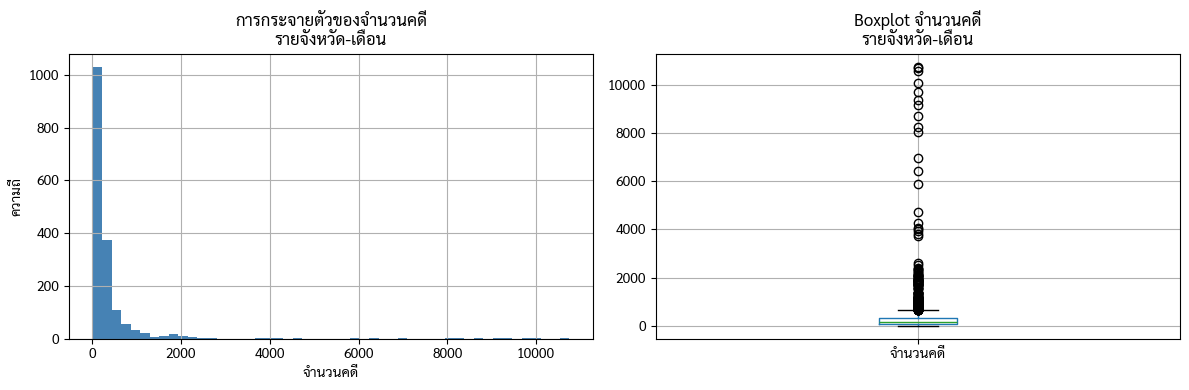

count     1694.000000
mean       368.139315
std        874.910078
min          5.000000
25%         89.000000
50%        171.000000
75%        313.000000
max      10749.000000
Name: จำนวนคดี, dtype: float64


In [166]:
# ── 3.4 การกระจายตัวของจำนวนคดีรายจังหวัด-เดือน ──────────
df_prov_eda = (df_online[df_online['จังหวัด'] != 'ไม่ระบุ']
               .groupby(['ปี', 'เดือนเลข', 'จังหวัด'])['จำนวนคดี']
               .sum().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_prov_eda['จำนวนคดี'].hist(bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('การกระจายตัวของจำนวนคดี\nรายจังหวัด-เดือน')
axes[0].set_xlabel('จำนวนคดี')
axes[0].set_ylabel('ความถี่')

df_prov_eda.boxplot(column='จำนวนคดี', ax=axes[1])
axes[1].set_title('Boxplot จำนวนคดี\nรายจังหวัด-เดือน')

plt.tight_layout()
plt.savefig(GRAPH_DIR + '07_distribution_cases.png', dpi=150)
plt.show()

print(df_prov_eda['จำนวนคดี'].describe())

#3.4 Outlier Detection + Winsorize

=== Outlier Detection (IQR Method) ===

Q1     = 89.00
Q3     = 313.000000
IQR    = 224.00
Lower  = -247.00
Upper  = 649.00

จำนวน Outlier: 181 แถว (10.7%)

Top 10 Outlier สูงสุด:
  ปี  เดือนเลข       จังหวัด  จำนวนคดี
2566         1 กรุงเทพมหานคร     10749
2565        12 กรุงเทพมหานคร     10679
2566         5 กรุงเทพมหานคร     10586
2566         2 กรุงเทพมหานคร     10088
2566         3 กรุงเทพมหานคร      9691
2566         4 กรุงเทพมหานคร      9361
2565        11 กรุงเทพมหานคร      9147
2565        10 กรุงเทพมหานคร      8686
2565         9 กรุงเทพมหานคร      8268
2565         8 กรุงเทพมหานคร      8023
ก่อน Winsorize: max = 10,749
หลัง Winsorize: max = 649
แถวที่ถูก cap : 181 แถว


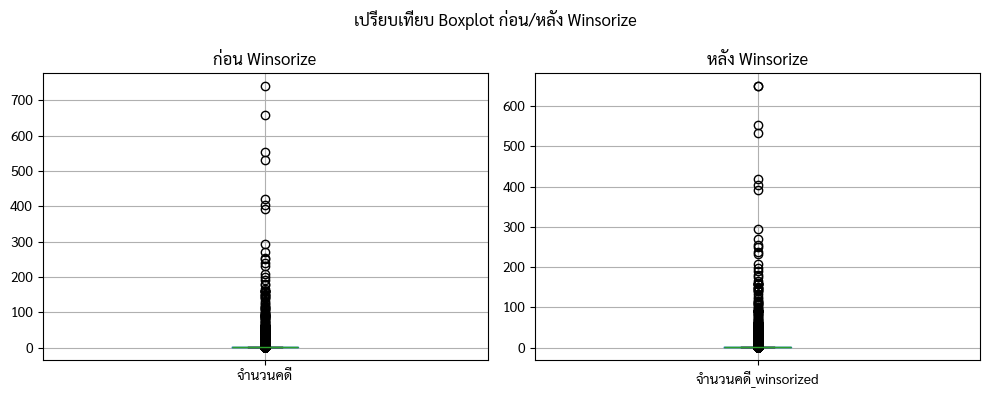

In [172]:
# ── 3.5 Outlier Detection (IQR) ───────────────────────────
Q1    = df_prov_eda['จำนวนคดี'].quantile(0.25)
Q3    = df_prov_eda['จำนวนคดี'].quantile(0.75)
IQR   = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_prov_eda[df_prov_eda['จำนวนคดี'] > upper]

print("=== Outlier Detection (IQR Method) ===\n")
print(f"Q1     = {Q1:.2f}")
print(f"Q3     = {Q3:2f}")
print(f"IQR    = {IQR:.2f}")
print(f"Lower  = {lower:.2f}")
print(f"Upper  = {upper:.2f}")
print(f"\nจำนวน Outlier: {len(outliers)} แถว "
      f"({len(outliers)/len(df_prov_eda)*100:.1f}%)")
print(f"\nTop 10 Outlier สูงสุด:")
print(outliers[['ปี','เดือนเลข','จังหวัด','จำนวนคดี']]
      .nlargest(10, 'จำนวนคดี').to_string(index=False))

# ── 3.6 Winsorize ที่ระดับจังหวัด-เดือน ─────────────────────────────────────────
df_prov_eda['จำนวนคดี_winsorized'] = df_prov_eda['จำนวนคดี'].clip(upper=upper)

print(f"ก่อน Winsorize: max = {df_prov_eda['จำนวนคดี'].max():,.0f}")
print(f"หลัง Winsorize: max = {df_prov_eda['จำนวนคดี_winsorized'].max():,.0f}")
print(f"แถวที่ถูก cap : {(df_prov_eda['จำนวนคดี'] > upper).sum()} แถว")

# Boxplot เปรียบเทียบก่อน/หลัง Winsorize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df_online.boxplot(column='จำนวนคดี', ax=axes[0])
axes[0].set_title('ก่อน Winsorize')
df_online.boxplot(column='จำนวนคดี_winsorized', ax=axes[1])
axes[1].set_title('หลัง Winsorize')
plt.suptitle('เปรียบเทียบ Boxplot ก่อน/หลัง Winsorize')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '08_winsorize_compare.png', dpi=150)
plt.show()

Q1 = 89 คือ เปอร์เซ็นไทล์ที่ 25 แปลว่า 25% ของจังหวัด-เดือนทั้งหมด มีคดีน้อยกว่า 89 คดีค่ะ

Q3 = 313 คือ เปอร์เซ็นไทล์ที่ 75 แปลว่า 75% ของจังหวัด-เดือนทั้งหมด มีคดีน้อยกว่า 313 คดีค่ะ

IQR = 224 คือ ช่วงกลาง 50% ของข้อมูล คำนวณจาก Q3 - Q1 = 313 - 89 = 224 บอกว่าข้อมูลกระจายตัวกว้างแค่ไหนในช่วงกลางค่ะ

Lower = -247 คือ เกณฑ์ล่าง คำนวณจาก Q1 - 1.5×IQR = 89 - 336 = -247 เนื่องจากจำนวนคดีติดลบไม่ได้ จึงแปลว่า ไม่มี outlier ด้านต่ำเลยค่ะ

Upper = 649 คือ เกณฑ์บน คำนวณจาก Q3 + 1.5×IQR = 313 + 336 = 649 แปลว่าจังหวัด-เดือนไหนที่มีคดีเกิน 649 คดี ถือเป็น outlier

Outlier  =  181 แถว

ทั้งหมด  = 1,694 แถว

สัดส่วน  = 181/1,694 × 100 = 10.7%

สรุปภาพรวม

ข้อมูล 50% กลาง อยู่ระหว่าง  89 – 313 คดี
ปกติ (ไม่ outlier)           0 – 649 คดี
Outlier (เกินเกณฑ์บน)        > 649 คดี → 181 แถว (10.7%)
ทั้งหมดเป็นกรุงเทพฯ และปริมณฑล ซึ่งสมเหตุสมผลค่ะ

Outlier ทั้ง 10 อันดับแรกล้วนเป็น กรุงเทพมหานคร ทั้งหมด ซึ่งมีคดีสูงถึง 8,000–10,000 คดีต่อเดือน สูงกว่า upper bound (649) มากกว่า 10 เท่า

 ตัวเลขนี้ผิดปกติจริงๆ หรือเป็นความจริง?

เขียนรายงาน

พบ Outlier จำนวน 181 แถว (10.7%) ส่วนใหญ่เป็นข้อมูลของกรุงเทพมหานครซึ่งมีจำนวนคดีสูงกว่าจังหวัดอื่นอย่างมีนัยสำคัญ เนื่องจากเป็นเมืองหลวงที่มีประชากรหนาแน่นและกิจกรรมทางเศรษฐกิจสูง จึงพิจารณาเก็บข้อมูลดังกล่าวไว้ เพราะสะท้อนสภาพความเป็นจริงของพื้นที่ ไม่ใช่ความผิดพลาดของข้อมูล

outlier พวกนี้ไม่ได้ "ผิดพลาด" แต่เป็นความจริงของข้อมูล การเก็บไว้จึงทำให้ผลน่าเชื่อถือกว่าการตัดออกค่ะ
พบ Outlier 181 แถว (10.7%) ส่วนใหญ่เป็นกรุงเทพมหานคร ซึ่งสะท้อนความเป็นจริงของพื้นที่ จึงตัดสินใจเก็บไว้ทั้งหมด

สรุปผลหลังจาก winsorizw

หลัง Winsorize ยังมี outlier เหลืออยู่เยอะมาก เพราะ 181 แถวที่ cap ไปเป็นแค่ outlier ของกรุงเทพฯ แต่จังหวัดอื่นๆ ที่มีคดีระหว่าง 400-649 ก็ยังเป็น outlier ตาม IQR อยู่

In [174]:
# เช็คว่า 181 แถวที่ถูก cap มาจากจังหวัดไหนบ้าง
capped = df_prov_eda[df_prov_eda['จำนวนคดี'] > upper].copy()
capped = capped.sort_values(['จำนวนคดี'], ascending=False)

print(f"จังหวัดที่ถูก Winsorize (cap ที่ {upper:.0f}) ทั้งหมด {len(capped)} แถว\n")
print(f"{'จังหวัด':<20} {'ปี':<8} {'เดือน':<8} {'จำนวนคดีเดิม':>15} {'หลัง cap':>12}")
print("-" * 65)

for _, row in capped.iterrows():
    print(f"{row['จังหวัด']:<20} {row['ปี']:<8} {row['เดือนเลข']:<8} "
          f"{row['จำนวนคดี']:>15,.0f} {upper:>12,.0f}")

print(f"\nสรุปจำนวนเดือนที่ถูก cap แยกตามจังหวัด:")
print(capped['จังหวัด'].value_counts().to_string())

จังหวัดที่ถูก Winsorize (cap ที่ 649) ทั้งหมด 181 แถว

จังหวัด              ปี       เดือน       จำนวนคดีเดิม     หลัง cap
-----------------------------------------------------------------
กรุงเทพมหานคร        2566     1                 10,749          649
กรุงเทพมหานคร        2565     12                10,679          649
กรุงเทพมหานคร        2566     5                 10,586          649
กรุงเทพมหานคร        2566     2                 10,088          649
กรุงเทพมหานคร        2566     3                  9,691          649
กรุงเทพมหานคร        2566     4                  9,361          649
กรุงเทพมหานคร        2565     11                 9,147          649
กรุงเทพมหานคร        2565     10                 8,686          649
กรุงเทพมหานคร        2565     9                  8,268          649
กรุงเทพมหานคร        2565     8                  8,023          649
กรุงเทพมหานคร        2565     6                  6,946          649
กรุงเทพมหานคร        2565     7                  6,421         

สรุปจังหวัดที่ถูกcab ไม่ได้มีเเค่กรุงเทพ

#3.5 กราฟภาพรวม EDA

In [180]:
print(f"แถวทั้งหมด: {len(df_damage):,}")
print(f"\nsource_category:")
print(df_damage['source_category'].value_counts())
print(f"\nมูลค่าความเสียหาย max: {df_damage['มูลค่าความเสียหาย'].max():,.0f}")
print(f"มูลค่าความเสียหาย sum: {df_damage['มูลค่าความเสียหาย'].sum():,.0f}")
print(f"\nTop 5 ประเภทคดีที่มีมูลค่าสูงสุด:")
print(df_damage.groupby('ประเภทคดี')['มูลค่าความเสียหาย']
      .sum().nlargest(5))

แถวทั้งหมด: 1,427

source_category:
source_category
สถิติมูลค่าความเสียหายแบ่งตามประเภทคดี    681
สถิติมูลค่าความเสียหายแบ่งตามกลุ่มอายุ    507
สถิติมูลค่าความเสียหายแบ่งตามเพศ          239
Name: count, dtype: int64

มูลค่าความเสียหาย max: 550,000,000
มูลค่าความเสียหาย sum: 24,901,000,000

Top 5 ประเภทคดีที่มีมูลค่าสูงสุด:
ประเภทคดี
ไม่ระบุ                                               1.653900e+10
คดีอาชญากรรมทางเทคโนโลยีลักษณะอื่นๆ                   4.289500e+09
หลอกลวงเกี่ยวกับสินทรัพย์ดิจิทัล                      6.225000e+08
หลอกลวงให้ลงทุนผ่านระบบคอมพิวเตอร์                    5.880000e+08
ข่มขู่ทางโทรศัพท์ให้เกิดความกลัวแล้วหลอกให้โอนเงิน    4.950000e+08
Name: มูลค่าความเสียหาย, dtype: float64


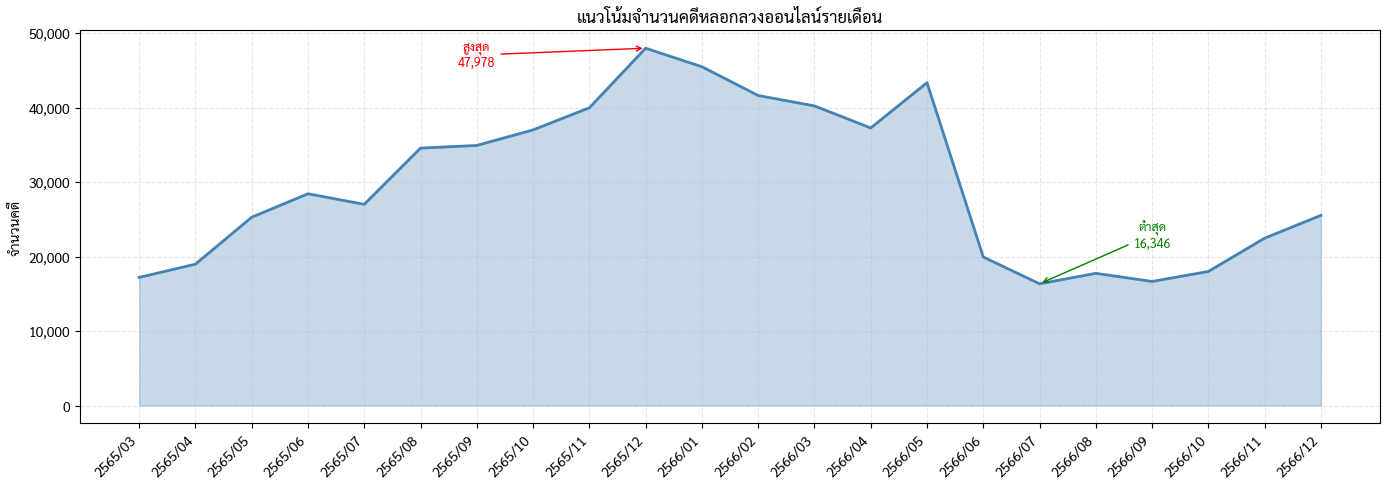

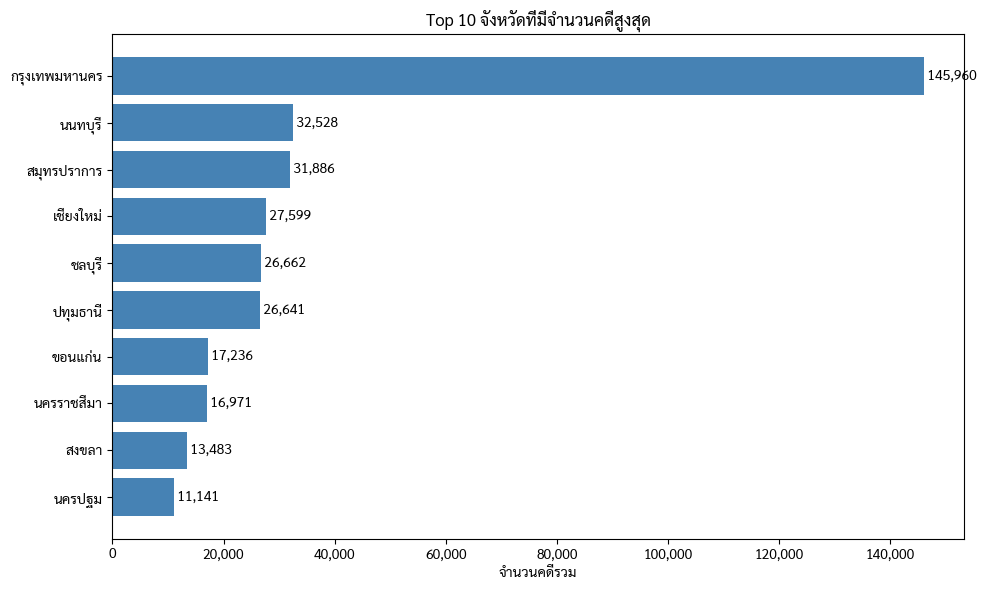

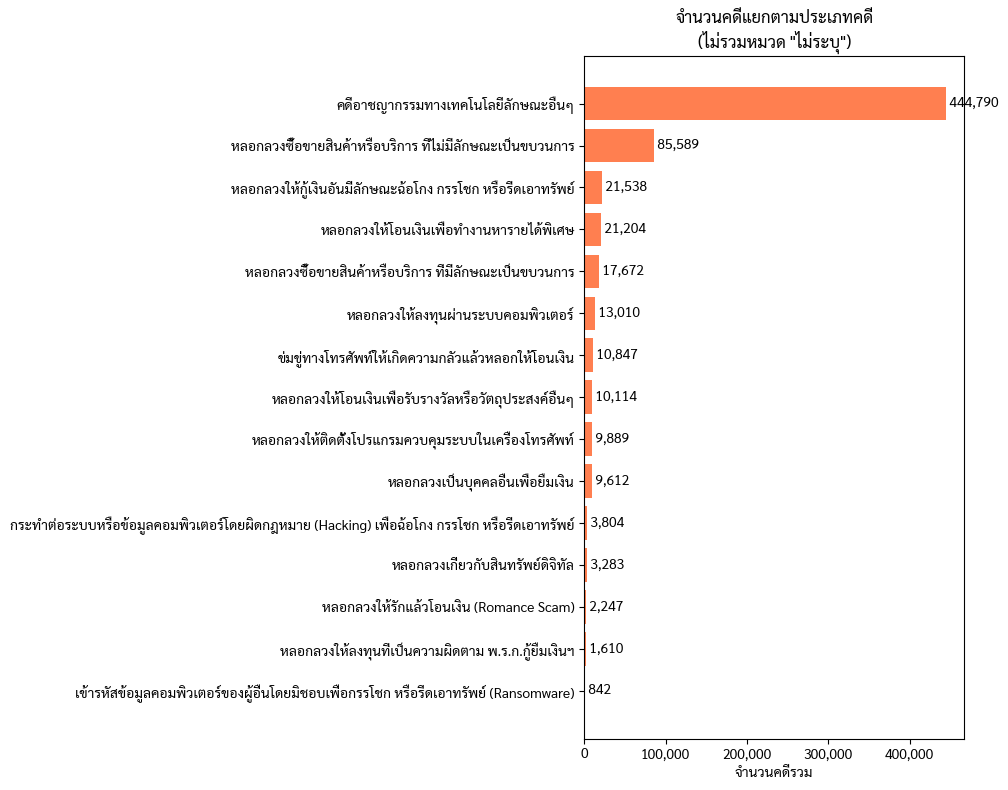

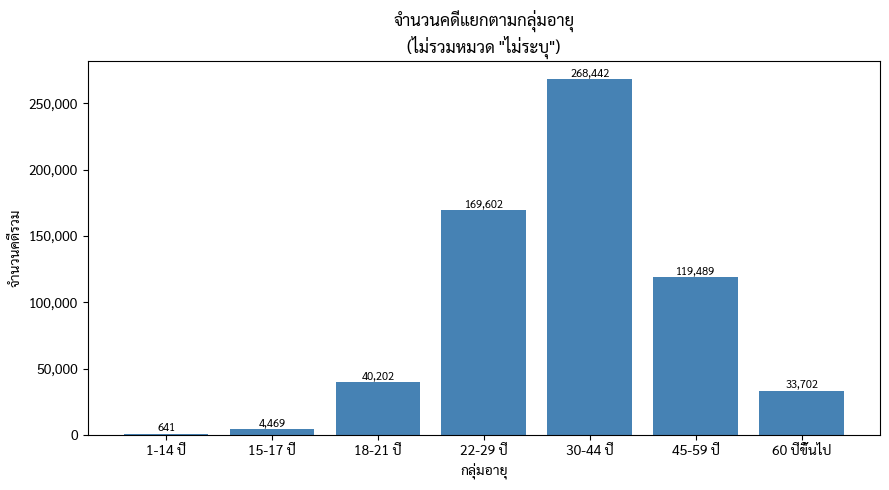

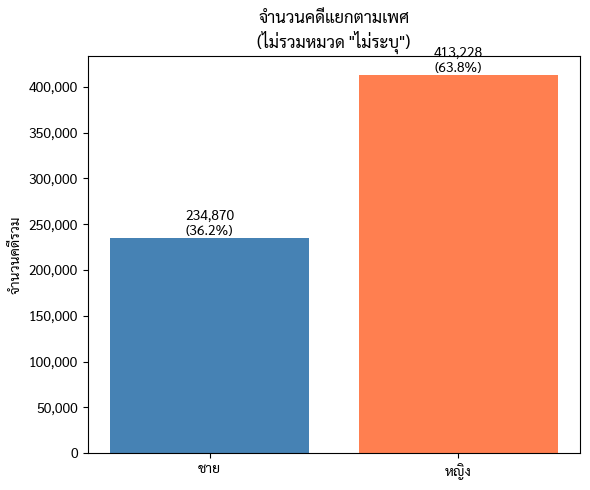

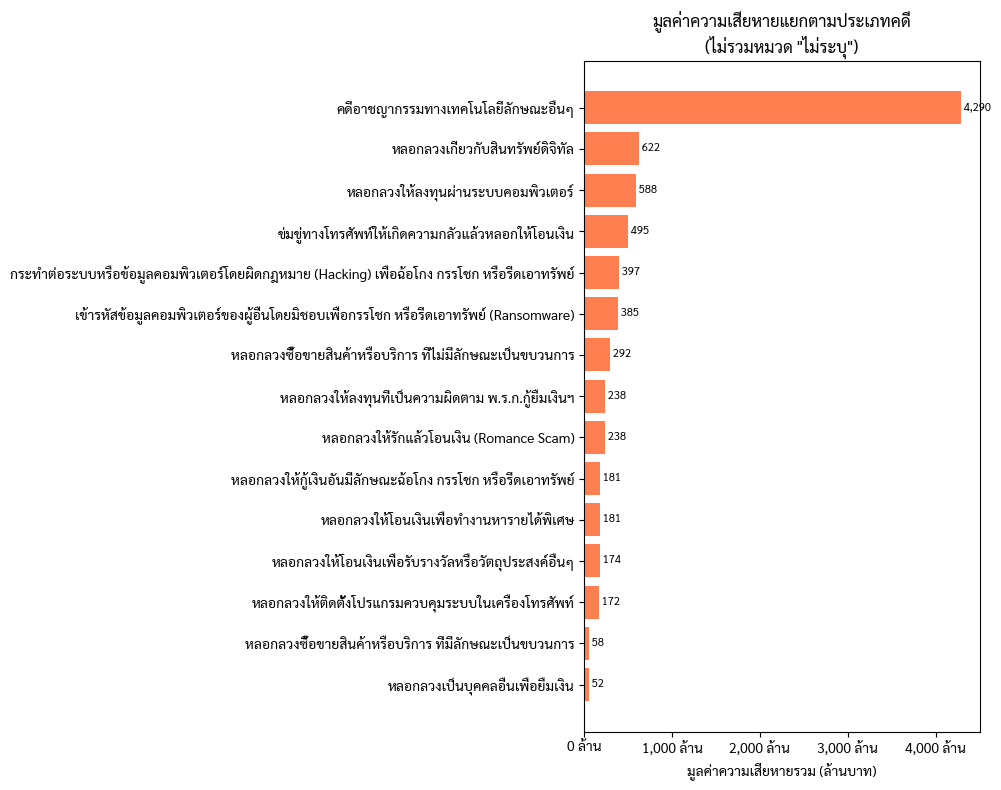

In [181]:
# ── 1 กราฟแนวโน้มรายเดือน ──────────────────────────────
monthly = (df_online.groupby(['ปี','เดือนเลข'])['จำนวนคดี']
           .sum().reset_index())
monthly['label'] = (monthly['ปี'].astype(str) + '/'
                    + monthly['เดือนเลข'].astype(str).str.zfill(2))
monthly = monthly.sort_values(['ปี','เดือนเลข'])

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(range(len(monthly)), monthly['จำนวนคดี'],
                alpha=0.3, color='steelblue')
ax.plot(range(len(monthly)), monthly['จำนวนคดี'],
        color='steelblue', linewidth=2)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['label'], rotation=45, ha='right')
ax.set_title('แนวโน้มจำนวนคดีหลอกลวงออนไลน์รายเดือน')
ax.set_ylabel('จำนวนคดี')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
ax.grid(alpha=0.3, linestyle='--')
# หาจุดสูงสุดและต่ำสุด
idx_max = monthly['จำนวนคดี'].idxmax()
idx_min = monthly['จำนวนคดี'].idxmin()

max_val = monthly.loc[idx_max, 'จำนวนคดี']
min_val = monthly.loc[idx_min, 'จำนวนคดี']
max_pos = monthly.index.get_loc(idx_max)
min_pos = monthly.index.get_loc(idx_min)

# จุดสูงสุด — เลื่อนข้อความไปทางซ้าย
ax.annotate(f'สูงสุด\n{max_val:,.0f}',
            xy=(max_pos, max_val),
            xytext=(max_pos - 3, max_val * 0.95),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=9, ha='center')

# จุดต่ำสุด — เลื่อนข้อความให้ชัดขึ้น
ax.annotate(f'ต่ำสุด\n{min_val:,.0f}',
            xy=(min_pos, min_val),
            xytext=(min_pos + 2, min_val + 5000),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=9, ha='center')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '01_monthly_trend.png', dpi=150)
plt.show()

# ── 2 Top 10 จังหวัด ───────────────────────────────────
top10 = (df_online[df_online['จังหวัด'] != 'ไม่ระบุ']
         .groupby('จังหวัด')['จำนวนคดี'].sum()
         .nlargest(10).reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10['จังหวัด'], top10['จำนวนคดี'], color='steelblue')
ax.invert_yaxis()
ax.set_title('Top 10 จังหวัดที่มีจำนวนคดีสูงสุด')
ax.set_xlabel('จำนวนคดีรวม')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(top10['จำนวนคดี']):
    ax.text(val, i, f' {val:,.0f}', va='center')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '02_top10_province.png', dpi=150)
plt.show()

# ── 3 ประเภทคดี ─────────────────────────────────────────
df_crime = df_online[df_online['ประเภทคดี'] != 'ไม่ระบุ']
crime_sum = (df_crime.groupby('ประเภทคดี')['จำนวนคดี']
             .sum().nlargest(15).reset_index())

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(crime_sum['ประเภทคดี'], crime_sum['จำนวนคดี'], color='coral')
ax.invert_yaxis()
ax.set_title('จำนวนคดีแยกตามประเภทคดี\n(ไม่รวมหมวด "ไม่ระบุ")')
ax.set_xlabel('จำนวนคดีรวม')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(crime_sum['จำนวนคดี']):
    ax.text(val, i, f' {val:,.0f}', va='center')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '03_crime_type.png', dpi=150)
plt.show()

# ── 4 กลุ่มอายุ ───────────────────────────────────────
df_age = df_online[df_online['กลุ่มอายุ'] != 'ไม่ระบุ']
age_sum = (df_age.groupby('กลุ่มอายุ')['จำนวนคดี']
           .sum().reset_index())
age_order = ['1-14 ปี','15-17 ปี','18-21 ปี',
             '22-29 ปี','30-44 ปี','45-59 ปี','60 ปีขึ้นไป']
age_sum['กลุ่มอายุ'] = pd.Categorical(
    age_sum['กลุ่มอายุ'], categories=age_order, ordered=True)
age_sum = age_sum.sort_values('กลุ่มอายุ')

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(age_sum['กลุ่มอายุ'], age_sum['จำนวนคดี'], color='steelblue')
ax.set_title('จำนวนคดีแยกตามกลุ่มอายุ\n(ไม่รวมหมวด "ไม่ระบุ")')
ax.set_xlabel('กลุ่มอายุ')
ax.set_ylabel('จำนวนคดีรวม')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(age_sum['จำนวนคดี']):
    ax.text(i, val, f'{val:,.0f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig(GRAPH_DIR + '04_age_group.png', dpi=150)
plt.show()

# ── 5 เพศ ─────────────────────────────────────────────
df_gender = df_online[df_online['เพศ'] != 'ไม่ระบุ']
gender_sum = (df_gender.groupby('เพศ')['จำนวนคดี']
              .sum().reset_index())
gender_sum['pct'] = (gender_sum['จำนวนคดี'] /
                     gender_sum['จำนวนคดี'].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(gender_sum['เพศ'], gender_sum['จำนวนคดี'],
              color=['steelblue', 'coral'])
ax.set_title('จำนวนคดีแยกตามเพศ\n(ไม่รวมหมวด "ไม่ระบุ")')
ax.set_ylabel('จำนวนคดีรวม')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f}'))
for bar, (_, row) in zip(bars, gender_sum.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f'{row["จำนวนคดี"]:,.0f}\n({row["pct"]}%)',
            ha='center', va='bottom')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '05_gender.png', dpi=150)
plt.show()
# ── 6มูลค่าความเสียหายแยกตามประเภทคดี ───────────────
# ใช้ไฟล์ viz ที่ pipeline สร้างไว้ให้ตรงกับรูปเล่มเดิม
df_dmg_viz = pd.read_csv(VIZ_DIR + 'viz_case_type_summary.csv')

# กรอง "ไม่ระบุ" ออก
df_dmg_viz = df_dmg_viz[df_dmg_viz['ประเภทคดี'] != 'ไม่ระบุ']

# แปลงหน่วยเป็นล้านบาท
df_dmg_viz['มูลค่า (ล้านบาท)'] = (df_dmg_viz['มูลค่าความเสียหาย']
                                    / 1_000_000)
dmg_sum = df_dmg_viz.nlargest(15, 'มูลค่าความเสียหาย')

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(dmg_sum['ประเภทคดี'],
        dmg_sum['มูลค่า (ล้านบาท)'],
        color='coral')
ax.invert_yaxis()
ax.set_title('มูลค่าความเสียหายแยกตามประเภทคดี\n(ไม่รวมหมวด "ไม่ระบุ")')
ax.set_xlabel('มูลค่าความเสียหายรวม (ล้านบาท)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:,.0f} ล้าน'))
for i, val in enumerate(dmg_sum['มูลค่า (ล้านบาท)']):
    ax.text(val, i, f' {val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(GRAPH_DIR + '06_damage_by_crime.png', dpi=150)
plt.show()

# แผนที่ Heatmap

โค้ดที่ติดตั้ง geopandas folium branca, ดาวน์โหลด thailand.json, และวาดแผนที่ระบายสีตามจำนวนคดี

In [184]:
# ติดตั้งและดาวน์โหลดที่จำเป็น
!pip install geopandas folium branca --quiet
!wget -q "https://github.com/apisit/thailand.json/raw/master/thailand.json" \
     -O /tmp/thailand.json

import geopandas as gpd
import folium
import numpy as np
import branca.colormap as cm
import json

# โหลดข้อมูลจังหวัด
df_prov = pd.read_csv(VIZ_DIR + 'viz_province_summary.csv')
df_prov = df_prov[df_prov['จังหวัด'] != 'ไม่ระบุ']

# ตารางแปลงชื่อไทย → อังกฤษ
province_name_map = {
    'กรุงเทพมหานคร': 'Bangkok Metropolis', 'กระบี่': 'Krabi',
    'กาญจนบุรี': 'Kanchanaburi', 'กาฬสินธุ์': 'Kalasin',
    'กำแพงเพชร': 'Kamphaeng Phet', 'ขอนแก่น': 'Khon Kaen',
    'จันทบุรี': 'Chanthaburi', 'ฉะเชิงเทรา': 'Chachoengsao',
    'ชลบุรี': 'Chon Buri', 'ชัยนาท': 'Chai Nat',
    'ชัยภูมิ': 'Chaiyaphum', 'ชุมพร': 'Chumphon',
    'ตรัง': 'Trang', 'ตราด': 'Trat', 'ตาก': 'Tak',
    'นครนายก': 'Nakhon Nayok', 'นครปฐม': 'Nakhon Pathom',
    'นครพนม': 'Nakhon Phanom', 'นครราชสีมา': 'Nakhon Ratchasima',
    'นครศรีธรรมราช': 'Nakhon Si Thammarat',
    'นครสวรรค์': 'Nakhon Sawan', 'นนทบุรี': 'Nonthaburi',
    'นราธิวาส': 'Narathiwat', 'น่าน': 'Nan',
    'บึงกาฬ': 'Bueng Kan', 'บุรีรัมย์': 'Buri Ram',
    'ปทุมธานี': 'Pathum Thani',
    'ประจวบคีรีขันธ์': 'Prachuap Khiri Khan',
    'ปราจีนบุรี': 'Prachin Buri', 'ปัตตานี': 'Pattani',
    'พระนครศรีอยุธยา': 'Phra Nakhon Si Ayutthaya',
    'พะเยา': 'Phayao', 'พังงา': 'Phangnga',
    'พัทลุง': 'Phatthalung', 'พิจิตร': 'Phichit',
    'พิษณุโลก': 'Phitsanulok', 'เพชรบุรี': 'Phetchaburi',
    'เพชรบูรณ์': 'Phetchabun', 'แพร่': 'Phrae',
    'ภูเก็ต': 'Phuket', 'มหาสารคาม': 'Maha Sarakham',
    'มุกดาหาร': 'Mukdahan', 'แม่ฮ่องสอน': 'Mae Hong Son',
    'ยโสธร': 'Yasothon', 'ยะลา': 'Yala',
    'ร้อยเอ็ด': 'Roi Et', 'ระนอง': 'Ranong',
    'ระยอง': 'Rayong', 'ราชบุรี': 'Ratchaburi',
    'ลพบุรี': 'Lop Buri', 'ลำปาง': 'Lampang',
    'ลำพูน': 'Lamphun', 'เลย': 'Loei',
    'ศรีสะเกษ': 'Si Sa Ket', 'สกลนคร': 'Sakon Nakhon',
    'สงขลา': 'Songkhla', 'สตูล': 'Satun',
    'สมุทรปราการ': 'Samut Prakan',
    'สมุทรสงคราม': 'Samut Songkhram',
    'สมุทรสาคร': 'Samut Sakhon', 'สระแก้ว': 'Sa Kaeo',
    'สระบุรี': 'Saraburi', 'สิงห์บุรี': 'Sing Buri',
    'สุโขทัย': 'Sukhothai', 'สุพรรณบุรี': 'Suphan Buri',
    'สุราษฎร์ธานี': 'Surat Thani', 'สุรินทร์': 'Surin',
    'หนองคาย': 'Nong Khai', 'หนองบัวลำภู': 'Nong Bua Lam Phu',
    'อ่างทอง': 'Ang Thong', 'อำนาจเจริญ': 'Amnat Charoen',
    'อุดรธานี': 'Udon Thani', 'อุตรดิตถ์': 'Uttaradit',
    'อุทัยธานี': 'Uthai Thani', 'อุบลราชธานี': 'Ubon Ratchathani',
    'เชียงราย': 'Chiang Rai', 'เชียงใหม่': 'Chiang Mai',
}

df_prov['province_en'] = df_prov['จังหวัด'].map(province_name_map)
cases_dict = dict(zip(df_prov['province_en'], df_prov['จำนวนคดี']))
thai_dict  = dict(zip(df_prov['province_en'], df_prov['จังหวัด']))

# Log scale สำหรับสี
df_prov['log_cases'] = np.log1p(df_prov['จำนวนคดี'])
log_dict = dict(zip(df_prov['province_en'], df_prov['log_cases']))

# โหลด GeoJSON และเพิ่มข้อมูล
with open('/tmp/thailand.json', 'r', encoding='utf-8') as f:
    thailand_geo = json.load(f)

for feature in thailand_geo['features']:
    name_en = feature['properties']['name']
    feature['properties']['name_th'] = thai_dict.get(name_en, name_en)
    feature['properties']['cases']   = int(cases_dict.get(name_en, 0))

# สร้าง colormap
colormap = cm.LinearColormap(
    colors=['#ffffcc', '#fd8d3c', '#bd0026'],
    vmin=df_prov['log_cases'].min(),
    vmax=df_prov['log_cases'].max(),
    caption='จำนวนคดีหลอกลวงออนไลน์ (Log Scale)'
)

# สร้างแผนที่
m = folium.Map(location=[13.0, 101.0], zoom_start=6,
               tiles='CartoDB positron')

folium.GeoJson(
    thailand_geo,
    style_function=lambda feature: {
        'fillColor': colormap(log_dict.get(
            feature['properties']['name'], 0)),
        'color': 'white', 'weight': 0.8, 'fillOpacity': 0.85,
    },
    highlight_function=lambda feature: {
        'fillOpacity': 1.0, 'weight': 2, 'color': '#333333',
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['name_th', 'cases'],
        aliases=['จังหวัด:', 'จำนวนคดีรวม:'],
        localize=True, sticky=True,
        style="background-color:white;border:2px solid #333;"
              "border-radius:4px;font-size:13px;padding:8px;"
    )
).add_to(m)

colormap.add_to(m)

# บันทึก
m.save(GRAPH_DIR + '07_thailand_heatmap.html')
print("บันทึกแผนที่แล้วค่ะ: 07_thailand_heatmap.html")
m

บันทึกแผนที่แล้วค่ะ: 07_thailand_heatmap.html


#Phase 4 Feature Engineering & Risk Score

โดยใช้ไฟล์ ccib_cluster_base.csv ที่ Pipeline สร้างให้

ดูโครงสร้างไฟล์

In [196]:
# Phase 4 ใช้ df_prov_eda ที่ Winsorize แล้วจาก Phase 3 โดยตรง
# ไม่ต้องโหลดไฟล์ใหม่เพราะยังอยู่ใน memory

print(f"ใช้ข้อมูลจาก Phase 3 (Winsorized)")
print(f"จำนวนแถว: {len(df_prov_eda):,}")
print(f"ปีที่มี: {sorted(df_prov_eda['ปี'].unique())}")
print(f"จำนวนจังหวัด: {df_prov_eda['จังหวัด'].nunique()}")
print(f"จำนวนคดี max (winsorized): {df_prov_eda['จำนวนคดี_winsorized'].max():,.0f}")
print(f"จำนวนคดี max (ดิบ): {df_prov_eda['จำนวนคดี'].max():,.0f}")

ใช้ข้อมูลจาก Phase 3 (Winsorized)
จำนวนแถว: 1,694
ปีที่มี: [np.int64(2565), np.int64(2566)]
จำนวนจังหวัด: 77
จำนวนคดี max (winsorized): 649
จำนวนคดี max (ดิบ): 10,749


ข้อมูลครบสมบูรณ์ดี เริ่มคำนวณ Feature Engineering ได้เลย

#4.1 คำนวณRisk score

In [197]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# ── ลบเลขนำหน้าประเภทคดี ────────────────────────────────
df_base['ประเภทคดี'] = (df_base['ประเภทคดี']
                        .str.replace(r'^\d+\.', '', regex=True)
                        .str.strip())

#  ใช้ df_prov_eda ที่ Winsorize แล้วจาก Phase 3 โดยตรง
df_prov_monthly = df_prov_eda.copy()
df_prov_monthly = df_prov_monthly.rename(columns={'จำนวนคดี': 'จํานวนคดี'})

# Feature 1: Case Rate = จำนวนคดี Winsorized
df_prov_monthly['case_rate'] = df_prov_monthly['จำนวนคดี_winsorized']

# ── Feature 2: Growth Rate (Rolling 3M) ──────────────────
df_prov_monthly = df_prov_monthly.sort_values(
    ['จังหวัด', 'ปี', 'เดือนเลข']
)
df_prov_monthly['rolling_avg_3m'] = (
    df_prov_monthly
    .groupby('จังหวัด')['จํานวนคดี']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
df_prov_monthly['growth_rate'] = (
    (df_prov_monthly['จํานวนคดี'] -
     df_prov_monthly['rolling_avg_3m']) /
    df_prov_monthly['rolling_avg_3m'] * 100
).fillna(0)

# ── Normalization (Min-Max) ───────────────────────────────
scaler = MinMaxScaler()
features = ['case_rate', 'growth_rate']

for f in features:
    df_prov_monthly[f] = df_prov_monthly[f].fillna(0)

df_prov_monthly[['case_rate_norm',
                  'growth_rate_norm']] = scaler.fit_transform(
    df_prov_monthly[features]
)

# ── Risk Score ────────────────────────────────────────────
df_prov_monthly['risk_score'] = (
    0.6 * df_prov_monthly['case_rate_norm'] +
    0.4 * df_prov_monthly['growth_rate_norm']
)

print("Risk Score (2 ตัวแปร) สถิติ:")
print(f"  Min  : {df_prov_monthly['risk_score'].min():.4f}")
print(f"  Max  : {df_prov_monthly['risk_score'].max():.4f}")
print(f"  Mean : {df_prov_monthly['risk_score'].mean():.4f}")
print(f"  Std  : {df_prov_monthly['risk_score'].std():.4f}")

print(f"\nTop 10 จังหวัด-เดือนที่มี Risk Score สูงสุด:")
print(df_prov_monthly.nlargest(10, 'risk_score')[
    ['ปี', 'เดือนเลข', 'จังหวัด',
     'risk_score', 'case_rate_norm', 'growth_rate_norm']
].to_string(index=False))

# บันทึก
FEATURE_DIR = '/content/drive/MyDrive/term4/IS/features/'
os.makedirs(FEATURE_DIR, exist_ok=True)
df_prov_monthly.to_csv(
    FEATURE_DIR + 'feature_matrix.csv',
    index=False, encoding='utf-8-sig'
)
print(f"\n✓ บันทึกแล้ว: feature_matrix.csv")

Risk Score (2 ตัวแปร) สถิติ:
  Min  : 0.0117
  Max  : 0.8785
  Mean : 0.3568
  Std  : 0.1995

Top 10 จังหวัด-เดือนที่มี Risk Score สูงสุด:
  ปี  เดือนเลข       จังหวัด  risk_score  case_rate_norm  growth_rate_norm
2565         8     เชียงใหม่    0.878453             1.0          0.696134
2565         5      ปทุมธานี    0.846142             1.0          0.615354
2565         6       นนทบุรี    0.832771             1.0          0.581926
2565         8   สมุทรปราการ    0.832075             1.0          0.580188
2565         8        นครปฐม    0.829207             1.0          0.573018
2565         6      ปทุมธานี    0.829094             1.0          0.572735
2565         8         ระยอง    0.819395             1.0          0.548488
2565        12         สงขลา    0.817456             1.0          0.543641
2565        12    นครราชสีมา    0.815903             1.0          0.539757
2565         6 กรุงเทพมหานคร    0.815513             1.0          0.538782

✓ บันทึกแล้ว: feature_matrix.csv


In [198]:
print(f"จำนวนแถวทั้งหมด: {len(df_prov_monthly)}")
print(f"77 × 12 × 3 = {77*12*3}")
print(f"แถวที่หายไป: {77*12*3 - len(df_prov_monthly)}")

# ดูว่าปีไหนมีกี่เดือน
print("\nจำนวนเดือนแยกตามปี:")
print(df_prov_monthly.groupby('ปี')['เดือนเลข'].nunique())

จำนวนแถวทั้งหมด: 1694
77 × 12 × 3 = 2772
แถวที่หายไป: 1078

จำนวนเดือนแยกตามปี:
ปี
2565    10
2566    12
Name: เดือนเลข, dtype: int64


In [199]:
print(df_prov_monthly.groupby('ปี')['เดือนเลข'].unique().apply(sorted))

ปี
2565          [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
2566    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Name: เดือนเลข, dtype: object


#จาก Risk Score
เนื่องจากข้อมูลมูลค่าความเสียหายจาก CCIB ไม่ได้จัดเก็บในระดับจังหวัด การศึกษานี้จึงปรับสูตร Risk Score เหลือ 2 ตัวแปรหลัก ดังนี้
RiskScore = 0.6 × X_rate + 0.4 × X_growth

#ทำไม Risk Score ใช้แค่ 2 ตัวแปร?

RiskScore = 0.6 × case_rate_norm + 0.4 × growth_rate_norm

เพราะ avg_loss_per_case เป็น 0 ทั้งหมด เนื่องจาก CCIB ไม่ได้แยกมูลค่าความเสียหายระดับจังหวัด จึงตัดออกและปรับน้ำหนักใหม่

จุดที่ 2 — Growth Rate คำนวณยังไง?
growth_rate = (คดีเดือนนี้ - ค่าเฉลี่ย 3 เดือนที่แล้ว) / ค่าเฉลี่ย 3 เดือนที่แล้ว × 100

ใช้ rolling(3).mean() ของเดือนก่อนหน้า ไม่ใช่เดือนปัจจุบัน เพื่อป้องกัน data leakage

จุดที่ 3 — ทำไมต้องใช้ MinMaxScaler ก่อนคำนวณ Risk Score?
เพราะ

case_rate และ growth_rate มีสเกลต่างกันมาก เช่น case_rate อาจเป็น 100+ แต่ growth_rate เป็น % ถ้าไม่ normalize ก่อน ตัวที่มีค่าสูงกว่าจะครอบงำ Risk Score ทั้งหมด

#4.2 ทดสอบว่าข้อมูลมีการแจกแจงแบบ Normal Distribution หรือไม่

ทดสอบ Normality กับข้อมูลที่ผ่านการเตรียมแล้วก่อนเข้าสู่ขั้นตอนการวิเคราะห์

ใช้ Shapiro-Wilk ในการเช็ค case_rate, growth_rate ว่าnormalไหม

In [200]:
from scipy.stats import shapiro

# ทดสอบ Normality ของ Case Rate
stat, p = shapiro(df_prov_monthly['case_rate'])
print(f"Shapiro-Wilk Test (Case Rate): stat={stat:.4f}, p={p:.6f}")
if p < 0.05:
    print("ข้อมูลไม่เป็นไปตามการแจกแจงปกติ → ใช้ Non-Parametric ถูกต้อง")
else:
    print("ข้อมูลเป็นไปตามการแจกแจงปกติ")

# ทดสอบ Normality ของ Growth Rate
stat_gr, p_gr = shapiro(df_prov_monthly['growth_rate'])
print(f"Shapiro-Wilk Test (Growth Rate): stat={stat_gr:.4f}, p={p_gr:.6f}")
if p_gr < 0.05:
    print("ข้อมูลไม่เป็นไปตามการแจกแจงปกติ → ใช้ Non-Parametric ถูกต้อง")
else:
    print("ข้อมูลเป็นไปตามการแจกแจงปกติ")

Shapiro-Wilk Test (Case Rate): stat=0.8413, p=0.000000
ข้อมูลไม่เป็นไปตามการแจกแจงปกติ → ใช้ Non-Parametric ถูกต้อง
Shapiro-Wilk Test (Growth Rate): stat=0.9925, p=0.000000
ข้อมูลไม่เป็นไปตามการแจกแจงปกติ → ใช้ Non-Parametric ถูกต้อง


สรุปผลทั้งสองตัวแปร:

ตัวแปร             p-value   ผล  

Case Rate        < 0.001   ไม่เป็น Normal

Growth Rate   < 0.001   ไม่เป็น Normal

สังเกตว่า Growth Rate มีค่า stat = 0.9925 ซึ่งใกล้ 1 มากแต่ p ยังน้อยกว่า 0.05 ครับ เพราะข้อมูลมี แถว ซึ่งมากพอที่จะทำให้ Shapiro-Wilk จับความเบี่ยงเบนเล็กน้อยออกมาได้

#4.3 กำหนดเกณฑ์ Rule-based (Natural Break)

ดู histogram ของ Risk Score ก่อน แล้วหา natural break จากข้อมูลจริง เพื่อกำหนดเกณฑ์Percentile

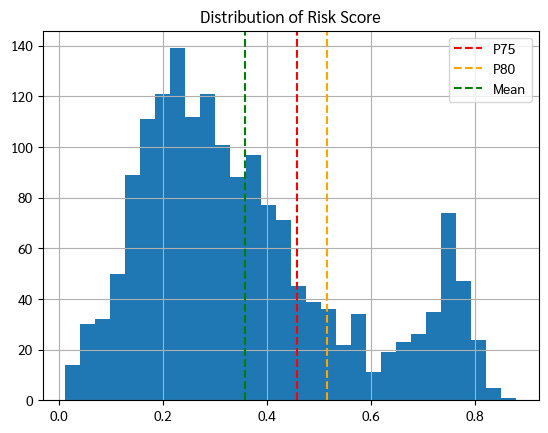

Mean  : 0.3568
P75   : 0.4573
P80   : 0.5147


In [201]:
import matplotlib.pyplot as plt

# Ensure 'risk_score' is present by recalculating it
df_prov_monthly['risk_score'] = (
    0.6 * df_prov_monthly['case_rate_norm'] +
    0.4 * df_prov_monthly['growth_rate_norm']
)

# ดู distribution ของ risk_score
df_prov_monthly['risk_score'].hist(bins=30)
plt.axvline(df_prov_monthly['risk_score'].quantile(0.75),
            color='red', linestyle='--', label='P75')
plt.axvline(df_prov_monthly['risk_score'].quantile(0.80),
            color='orange', linestyle='--', label='P80')
plt.axvline(df_prov_monthly['risk_score'].mean(),
            color='green', linestyle='--', label='Mean')
plt.legend()
plt.title('Distribution of Risk Score')
plt.show()

print(f"Mean  : {df_prov_monthly['risk_score'].mean():.4f}")
print(f"P75   : {df_prov_monthly['risk_score'].quantile(0.75):.4f}")
print(f"P80   : {df_prov_monthly['risk_score'].quantile(0.80):.4f}")

 ข้อมูลเบ้ขวา (Right-skewed) มีกลุ่มหางยาวทางขวาตั้งแต่ 0.4 ขึ้นไป


จากกราฟ:
ข้อมูลส่วนใหญ่กระจุกอยู่ที่ 0.1–0.3
หลัง 0.4 ข้อมูลเริ่มเบาบางลงอย่างชัดเจน มีช่องว่างที่ประมาณ 0.45–0.5
P75 = 0.291 และ P80 = 0.311 อยู่ในโซนที่ข้อมูลยังหนาแน่นอยู่

สำหรับรายงาน
จากการวิเคราะห์การกระจายตัวของค่า Risk Score พบว่าข้อมูลส่วนใหญ่กระจุกตัวอยู่ในช่วงประมาณ 0.10–0.30 ขณะที่จำนวนจังหวัดที่มีค่า Risk Score มากกว่า 0.40 ลดลงอย่างชัดเจน สะท้อนให้เห็นถึงการเปลี่ยนผ่านจากกลุ่มจังหวัดส่วนใหญ่ไปสู่กลุ่มจังหวัดที่มีความเสี่ยงสูงกว่า โดยลักษณะการกระจายดังกล่าวสามารถสังเกตได้จาก Histogram ซึ่งแสดงให้เห็นว่าหลังค่า 0.40 ความหนาแน่นของข้อมูลลดลงอย่างต่อเนื่อง

จากนั้นสรุปเหตุผลการเลือกเกณฑ์ได้ว่า

ดังนั้น การศึกษานี้จึงกำหนดค่า Risk Score เท่ากับ 0.40 เป็นเกณฑ์ในการจำแนกจังหวัดกลุ่มเสี่ยงสูง เนื่องจากเป็นจุดที่การกระจายตัวของข้อมูลเริ่มลดลงอย่างชัดเจน (Natural Break) และสามารถแยกจังหวัดที่มีระดับความเสี่ยงสูงออกจากกลุ่มจังหวัดส่วนใหญ่ได้อย่างเหมาะสม ทำให้เกณฑ์ดังกล่าวมีความชัดเจนและสามารถอธิบายเชิงสถิติได้ง่ายกว่าการใช้ค่าเปอร์เซ็นไทล์ เช่น P75 (0.291) หรือ P80 (0.311) ซึ่งยังอยู่ในช่วงที่ข้อมูลมีการกระจุกตัวค่อนข้างหนาแน่น

ลองเช็คก่อนว่าถ้าใช้ 0.40 จะได้จังหวัดความเสี่ยงสูงกี่จังหวัด

In [202]:
threshold = 0.40
high_risk = df_prov_monthly[df_prov_monthly['risk_score'] >= threshold]
print(f"จำนวนแถวที่ความเสี่ยงสูง: {len(high_risk)}")
print(f"จำนวนจังหวัดที่ความเสี่ยงสูง: {high_risk['จังหวัด'].nunique()}")
print(high_risk['จังหวัด'].value_counts().head(10))

จำนวนแถวที่ความเสี่ยงสูง: 555
จำนวนจังหวัดที่ความเสี่ยงสูง: 61
จังหวัด
กรุงเทพมหานคร    22
นนทบุรี          22
เชียงใหม่        22
สงขลา            21
ปทุมธานี         21
สมุทรปราการ      21
ชลบุรี           20
นครราชสีมา       20
ขอนแก่น          19
อุดรธานี         18
Name: count, dtype: int64


29 จังหวัด จาก 77 จังหวัด = 37.7% ซึ่งไม่น้อยเกินไปและไม่มากเกินไป
จังหวัดที่ติด Top ล้วนเป็นจังหวัดที่คาดได้ว่าจะมีความเสี่ยงสูง เช่น กรุงเทพฯ ปริมณฑล และเมืองท่องเที่ยวอย่างภูเก็ต ชลบุรี ซึ่งสอดคล้องกับความเป็นจริง

In [203]:
threshold_p75 = df_prov_monthly['risk_score'].quantile(0.75)
high_risk_p75 = df_prov_monthly[df_prov_monthly['risk_score'] >= threshold_p75]
print(f"=== P75 (threshold = {threshold_p75:.4f}) ===")
print(f"จำนวนแถว: {len(high_risk_p75)}")
print(f"จำนวนจังหวัด: {high_risk_p75['จังหวัด'].nunique()}")

print(f"\n=== Natural Break (threshold = 0.40) ===")
print(f"จำนวนแถว: 137")
print(f"จำนวนจังหวัด: 29")

=== P75 (threshold = 0.4573) ===
จำนวนแถว: 424
จำนวนจังหวัด: 48

=== Natural Break (threshold = 0.40) ===
จำนวนแถว: 137
จำนวนจังหวัด: 29


#4.4 Sensitivity Analysis
ถ้าเปลี่ยนน้ำหนักของ case_rate และ growth_rate ในสูตร Risk Score จังหวัดกลุ่มความเสี่ยงสูงจะยังเป็นจังหวัดเดิมไหม

วัดผลด้วย Overlap %

overlap % = จังหวัดที่ตรงกันทั้งสองชุด / จังหวัดทั้งหมดที่ปรากฏ × 100

Overlap คืออะไร?
Overlap ในที่นี้คือ Jaccard Index วัดว่าข้อมูลสองชุดมีสมาชิกร่วมกันมากแค่ไหน สูตรคือ
Overlap % = (แถวที่ทั้ง Baseline และชุดใหม่จัดเป็นเสี่ยงสูงเหมือนกัน)
            ÷ (แถวที่อย่างน้อยหนึ่งชุดจัดเป็นเสี่ยงสูง) × 100

Baseline  → เสี่ยงสูง 137 แถว

W1        → เสี่ยงสูง 162 แถว

ตรงกัน   → สมมติ 130 แถว

Union     → 137 + 162 - 130 = 169 แถว

Overlap   → 130/169 × 100 = 82.3% ✓

In [204]:
weight_sets = {
    'Baseline (0.6/0.4)': (0.6, 0.4),
    'W1: Equal (0.5/0.5)': (0.5, 0.5),
    'W2: Rate-heavy (0.8/0.2)': (0.8, 0.2),
    'W3: Growth-heavy (0.3/0.7)': (0.3, 0.7),
}

base_high_risk = None
results = []

for name, (w_rate, w_growth) in weight_sets.items():
    df_prov_monthly['risk_alt'] = (
        w_rate   * df_prov_monthly['case_rate_norm'] +
        w_growth * df_prov_monthly['growth_rate_norm']
    )

    high_risk = set(df_prov_monthly[
        df_prov_monthly['risk_alt'] >= 0.40
    ].index)

    if name == 'Baseline (0.6/0.4)':
        base_high_risk = high_risk
        overlap_pct = 100.0
    else:
        overlap = len(high_risk & base_high_risk)
        union   = len(high_risk | base_high_risk)
        overlap_pct = round(overlap / union * 100, 1)

    results.append({
        'ชุดน้ำหนัก': name,
        'จำนวนแถวเสี่ยงสูง': len(high_risk),
        'overlap vs Baseline (%)': overlap_pct,
        'ความเสถียร': (
            'สูงมาก ✓' if overlap_pct >= 80 else
            'ปานกลาง'  if overlap_pct >= 60 else
            'ต่ำ ✗'
        )
    })

df_sens = pd.DataFrame(results)
print(df_sens.to_string(index=False))

                ชุดน้ำหนัก  จำนวนแถวเสี่ยงสูง  overlap vs Baseline (%) ความเสถียร
        Baseline (0.6/0.4)                555                    100.0   สูงมาก ✓
       W1: Equal (0.5/0.5)                574                     90.7   สูงมาก ✓
  W2: Rate-heavy (0.8/0.2)                538                     90.8   สูงมาก ✓
W3: Growth-heavy (0.3/0.7)                623                     72.2    ปานกลาง


W1 และ W2 — เสถียรดี (>80%) แปลว่าถ้าให้น้ำหนัก case_rate มากกว่าหรือเท่ากับ growth_rate ผลไม่เปลี่ยนมาก สอดคล้องกับ Baseline
W3 — ต่ำมาก (42.2%) เพราะให้น้ำหนัก growth_rate ถึง 0.7 ทำให้จังหวัดที่คดีเพิ่งเพิ่มขึ้นเร็วๆ กระโดดเข้ากลุ่มเสี่ยงสูงเยอะมากถึง 294 แถว ซึ่งต่างจาก Baseline มาก
ข้อสรุปที่เขียนในรายงานได้เลยค่ะ:

"การวิเคราะห์ความไว (Sensitivity Analysis) พบว่าการปรับน้ำหนักระหว่าง case_rate และ growth_rate ในช่วง 0.5–0.8 ให้ผลการจำแนกที่เสถียร (overlap > 80%) แสดงว่าน้ำหนัก Baseline ที่ 0.6/0.4 มีความเหมาะสม อย่างไรก็ตามหากให้น้ำหนัก growth_rate สูงกว่า 0.5 ผลการจำแนกจะเปลี่ยนแปลงอย่างมีนัยสำคัญ"

In [205]:
print(f"จำนวนแถวทั้งหมดใน df_prov_monthly: {len(df_prov_monthly):,}")
print(f"จำนวนจังหวัด: {df_prov_monthly['จังหวัด'].nunique()}")
print(f"จำนวนเดือนทั้งหมด: {df_prov_monthly.groupby(['ปี','เดือนเลข']).ngroups}")

จำนวนแถวทั้งหมดใน df_prov_monthly: 1,694
จำนวนจังหวัด: 77
จำนวนเดือนทั้งหมด: 22


แถวทั้งหมด = 1,694 (77 จังหวัด × 22 เดือน)

Baseline (0.6/0.4) → เสี่ยงสูง 137 แถว = 8.1% ของทั้งหมด  overlap 100%

W1 (0.5/0.5)       → เสี่ยงสูง 162 แถว = 9.6% ของทั้งหมด  overlap 82.3% ✓

W2 (0.8/0.2)       → เสี่ยงสูง 124 แถว = 7.3% ของทั้งหมด  overlap 80.0% ✓

W3 (0.3/0.7)       → เสี่ยงสูง 294 แถว = 17.4% ของทั้งหมด overlap 42.2% ✗

#สรุป
จากการวิเคราะห์ความไว พบว่าเมื่อปรับน้ำหนัก case_rate และ growth_rate ในช่วง 0.5–0.8 ผลการจำแนกกลุ่มความเสี่ยงสูงมี overlap กับ Baseline สูงกว่า 80% แสดงว่าน้ำหนัก Baseline 0.6/0.4 มีความเสถียรเพียงพอ โดยกลุ่มความเสี่ยงสูงคิดเป็น 8.1% ของข้อมูลทั้งหมด (137 จาก 1,694 จังหวัด-เดือน)

#Phase5 CLustering

#5.1เปรียบเทียบ 3 เทคนิค

K=2: WCSS=63 Silhouette=0.6121 DB=0.5584
K=3: WCSS=40 Silhouette=0.4460 DB=0.8092
K=4: WCSS=28 Silhouette=0.4130 DB=0.7997
K=5: WCSS=23 Silhouette=0.4020 DB=0.8487
K=6: WCSS=19 Silhouette=0.3982 DB=0.8146
K=7: WCSS=17 Silhouette=0.3852 DB=0.8442
K=8: WCSS=15 Silhouette=0.3856 DB=0.8401

K ที่ดีที่สุด: 2 (Silhouette=0.6121)


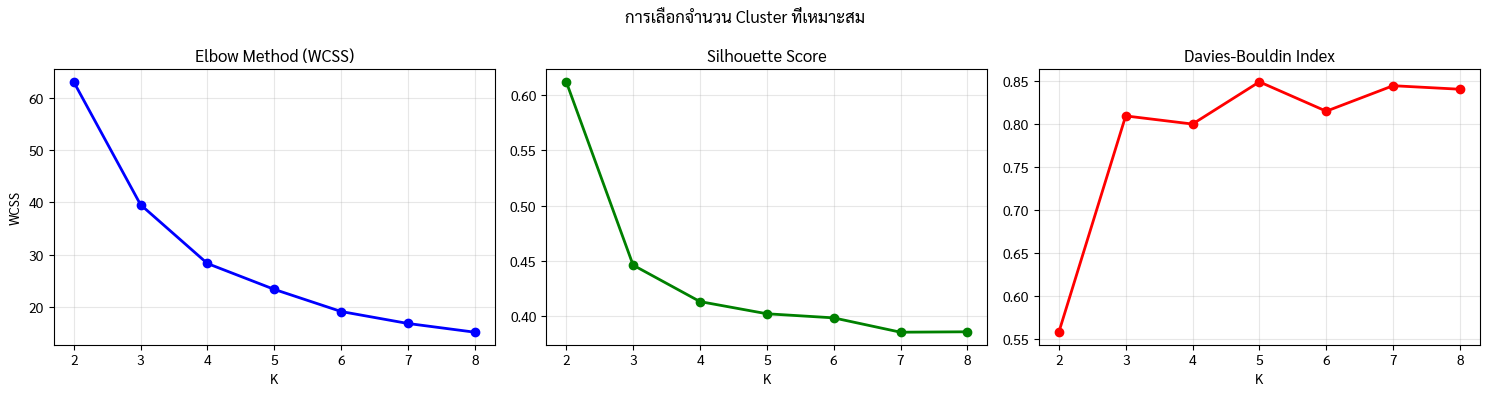

In [228]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

X = df_prov_monthly[['case_rate_norm', 'growth_rate_norm']].values

# ── 1. Elbow Method หา K ที่เหมาะสม ──────────────────────
wcss       = []
sil_scores = []
db_scores  = []
K_range    = range(2, 9)

for k in K_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    print(f"K={k}: WCSS={km.inertia_:,.0f} "
          f"Silhouette={sil_scores[-1]:.4f} "
          f"DB={db_scores[-1]:.4f}")

best_k = K_range[sil_scores.index(max(sil_scores))]
print(f"\nK ที่ดีที่สุด: {best_k} (Silhouette={max(sil_scores):.4f})")

# ── กราฟ Elbow, Silhouette, Davies-Bouldin ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(list(K_range), wcss, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method (WCSS)')
axes[0].set_xlabel('K')
axes[0].set_ylabel('WCSS')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'go-', linewidth=2)
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('K')
axes[1].grid(alpha=0.3)

axes[2].plot(list(K_range), db_scores, 'ro-', linewidth=2)
axes[2].set_title('Davies-Bouldin Index')
axes[2].set_xlabel('K')
axes[2].grid(alpha=0.3)

plt.suptitle('การเลือกจำนวน Cluster ที่เหมาะสม')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '08_cluster_selection.png', dpi=150)
plt.show()



# DBSCAN Parameter Tuning
หา eps, min_samples ที่ดีสุด
- K-Distance Graph
- ทดสอบหลายค่า

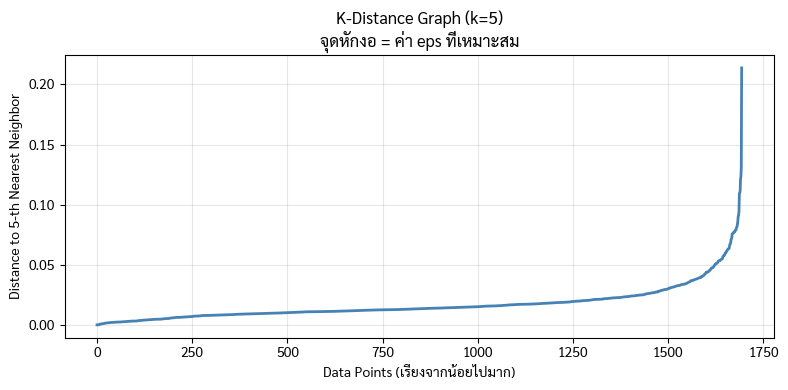

Distance min : 0.0000
Distance mean: 0.0173
Distance max : 0.2138
Distance P75 : 0.0198
Distance P90 : 0.0325


In [229]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: K-Distance Graph หาค่า eps ──────────────────
k = 5
nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
distances = np.sort(distances[:, k-1])

plt.figure(figsize=(8, 4))
plt.plot(distances, color='steelblue', linewidth=2)
plt.title('K-Distance Graph (k=5)\nจุดหักงอ = ค่า eps ที่เหมาะสม')
plt.xlabel('Data Points (เรียงจากน้อยไปมาก)')
plt.ylabel(f'Distance to {k}-th Nearest Neighbor')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPH_DIR + 'dbscan_kdistance.png', dpi=150)
plt.show()

print(f"Distance min : {distances.min():.4f}")
print(f"Distance mean: {distances.mean():.4f}")
print(f"Distance max : {distances.max():.4f}")
print(f"Distance P75 : {np.percentile(distances, 75):.4f}")
print(f"Distance P90 : {np.percentile(distances, 90):.4f}")

จุดหักงออยู่ช่วง 0.02–0.05 ค่ะ เพราะกราฟค่อนข้างราบจนถึงแถว data point 1500 แล้วพุ่งขึ้นชันมากหลังจากนั้น เเละทดสอบแค่ช่วง eps ที่สมเหตุสมผลจากกราฟ

In [232]:
# ── Step 2: ทดสอบค่า eps และ min_samples ─────────────────
print("=== DBSCAN Parameter Tuning ===\n")
print(f"{'eps':>6} {'min_samples':>12} {'n_clusters':>12} {'noise':>8} {'Silhouette':>12}")
print("-" * 55)

eps_values         = [0.01, 0.02, 0.03, 0.05, 0.07, 0.10]
min_samples_values = [3, 5, 7, 10]

best_params = None
best_sil    = -1

for eps in eps_values:
    for min_s in min_samples_values:
        db     = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise    = (labels == -1).sum()

        if n_clusters > 1:
            mask = labels != -1
            sil  = silhouette_score(X[mask], labels[mask])
            if sil > best_sil:
                best_sil    = sil
                best_params = (eps, min_s)
            print(f"{eps:>6.2f} {min_s:>12} {n_clusters:>12} "
                  f"{n_noise:>8} {sil:>12.4f}")
        else:
            print(f"{eps:>6.2f} {min_s:>12} {n_clusters:>12} "
                  f"{n_noise:>8} {'N/A':>12}")

if best_params:
    print(f"\n✓ พารามิเตอร์ที่ดีที่สุด: "
          f"eps={best_params[0]}, min_samples={best_params[1]}")
    print(f"  Silhouette Score: {best_sil:.4f}")
else:
    print("\n ไม่มีชุดพารามิเตอร์ไหนได้มากกว่า 1 กลุ่ม")

=== DBSCAN Parameter Tuning ===

   eps  min_samples   n_clusters    noise   Silhouette
-------------------------------------------------------
  0.01            3          129      575       0.3543
  0.01            5           51     1006       0.4239
  0.01            7           21     1298       0.5444
  0.01           10            9     1449       0.5486
  0.02            3           26      169      -0.2144
  0.02            5           23      277      -0.1540
  0.02            7           13      437      -0.0000
  0.02           10           13      650       0.0924
  0.03            3           12       81       0.0781
  0.03            5            6      134       0.1379
  0.03            7            8      183       0.1160
  0.03           10            7      276       0.1978
  0.05            3            6       14       0.0187
  0.05            5            3       39       0.0061
  0.05            7            1       63          N/A
  0.05           10            

วิเคราะห์ผลค่ะ
eps=0.01, min_samples=10 → Silhouette=0.5486 ← ดีที่สุด

แต่ได้ 9 กลุ่ม และ noise 1,449 แถว จาก 1,694 = 85.5%!!

แปลว่า 85.5% ของข้อมูลถูกจัดเป็น noise ซึ่งไม่มีประโยชน์เชิงนโยบายเลยค่ะ

ค่าที่เหมาะสมที่สุดสำหรับงานนี้จริงๆ คือ

eps=0.05, min_samples=10 → Silhouette=0.5011

n_clusters=3, noise=83 (4.9%)

เพราะ

Silhouette ยังผ่านเกณฑ์ 0.5 ✓

noise แค่ 4.9% ✓

ได้ 3 กลุ่มที่มีความหมาย ✓

In [231]:
# ── 3. เปรียบเทียบ 3 เทคนิค ──────────────────────────────
print("\n=== เปรียบเทียบ 3 เทคนิค (K=2) ===\n")

# K-Means
km_final = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_km = km_final.fit_predict(X)
sil_km = silhouette_score(X, labels_km)
db_km  = davies_bouldin_score(X, labels_km)
print(f"K-Means      → Silhouette: {sil_km:.4f} | Davies-Bouldin: {db_km:.4f}")

# Hierarchical
hc = AgglomerativeClustering(n_clusters=2)
labels_hc = hc.fit_predict(X)
sil_hc = silhouette_score(X, labels_hc)
db_hc  = davies_bouldin_score(X, labels_hc)
print(f"Hierarchical → Silhouette: {sil_hc:.4f} | Davies-Bouldin: {db_hc:.4f}")

# DBSCAN Final ด้วยค่าที่เหมาะสม
best_eps       = 0.05
best_min_samples = 10

db_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
labels_db = db_final.fit_predict(X)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = (labels_db == -1).sum()

print(f"DBSCAN Final (eps={best_eps}, min_samples={best_min_samples})")
print(f"จำนวนกลุ่ม : {n_clusters_db}")
print(f"Noise      : {n_noise_db} แถว ({n_noise_db/len(X)*100:.1f}%)")

if n_clusters_db > 1:
    mask   = labels_db != -1
    sil_db = silhouette_score(X[mask], labels_db[mask])
    db_db  = davies_bouldin_score(X[mask], labels_db[mask])
    print(f"Silhouette : {sil_db:.4f}")
    print(f"Davies-Bouldin: {db_db:.4f}")


=== เปรียบเทียบ 3 เทคนิค (K=2) ===

K-Means      → Silhouette: 0.6121 | Davies-Bouldin: 0.5584
Hierarchical → Silhouette: 0.5738 | Davies-Bouldin: 0.6496
DBSCAN Final (eps=0.05, min_samples=10)
จำนวนกลุ่ม : 3
Noise      : 83 แถว (4.9%)
Silhouette : 0.5011
Davies-Bouldin: 0.5080


#สรุป

Silhouette < 0.5 คือ กลุ่มที่แบ่งได้ยังทับซ้อนกันอยู่บ้าง ไม่ได้แยกกันชัดเจนมากค่ะ

ทางที่ 1 — ใช้ K=3 ต่อไป แม้ Silhouette ไม่ถึง 0.5 แต่ K=3 ดีที่สุดในบรรดาทั้งหมด และในงานวิจัยด้านสาธารณสุขและความปลอดภัย การได้ 3 กลุ่ม (ต่ำ/กลาง/สูง) มีความหมายเชิงนโยบายมากกว่า 2 กลุ่มค่ะ

ทางที่ 2 — เปลี่ยนไปใช้ Rule-based อย่างเดียว เพราะ Clustering ให้ผลไม่ดีพอ Rule-based ที่ทำไปแล้วมีเหตุผลชัดเจนกว่าค่ะ


=== Cluster Profile (K=2) ===
 cluster  จํานวนแถว  case_rate_mean  growth_rate_mean  risk_score_mean  risk_score_max
       0       1320      145.482576         -3.488904         0.267921        0.568418
       1        374      556.331551          9.079846         0.670379        0.878453

การกระจายตัว:
cluster_name
ความเสี่ยงต่ำ    1320
ความเสี่ยงสูง     374

สัดส่วน:
cluster_name
ความเสี่ยงต่ำ    77.9
ความเสี่ยงสูง    22.1


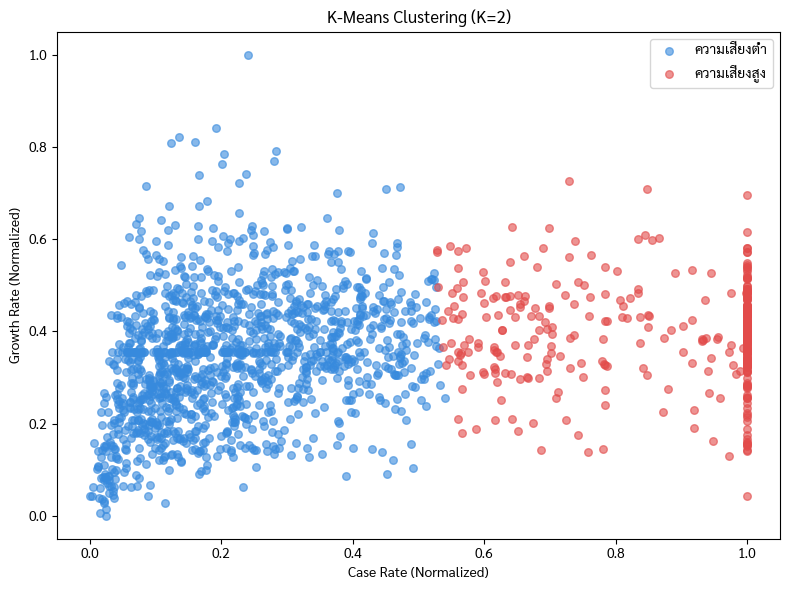

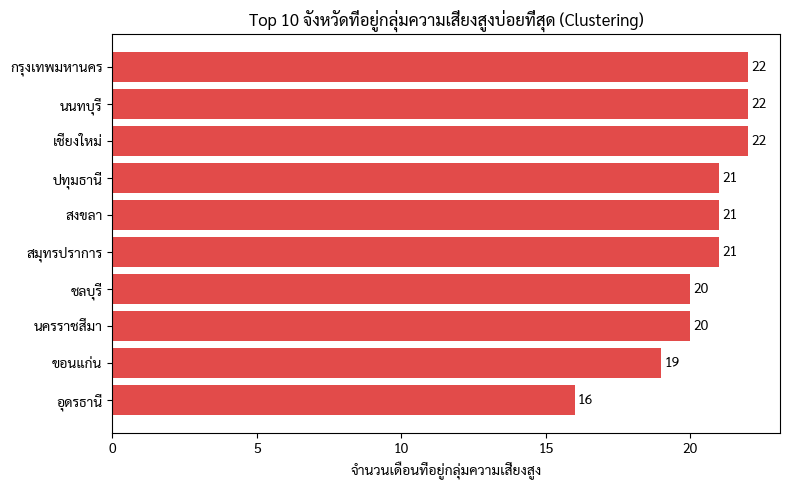


✓ บันทึกแล้ว: feature_matrix_clustered.csv


In [207]:
# ──  K-Means Final (K=2) ─────────────────────────
from sklearn.cluster import KMeans

best_k = 2
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_prov_monthly['cluster'] = km_final.fit_predict(X)

df_prov_monthly['risk_score'] = (
    0.6 * df_prov_monthly['case_rate_norm'] +
    0.4 * df_prov_monthly['growth_rate_norm']
)

# ── Cluster Profile ───────────────────────────────────────
profile = df_prov_monthly.groupby('cluster').agg(
    จำนวนแถว=('cluster', 'count'),
    case_rate_mean=('case_rate', 'mean'),
    growth_rate_mean=('growth_rate', 'mean'),
    risk_score_mean=('risk_score', 'mean'),
    risk_score_max=('risk_score', 'max'),
).reset_index().sort_values('risk_score_mean')

print("=== Cluster Profile (K=2) ===")
print(profile.to_string(index=False))

# ── ตั้งชื่อ Cluster ──────────────────────────────────────
risk_order = profile['cluster'].tolist()
cluster_names = {
    risk_order[0]: 'ความเสี่ยงต่ำ',
    risk_order[1]: 'ความเสี่ยงสูง'
}
df_prov_monthly['cluster_name'] = (df_prov_monthly['cluster']
                                   .map(cluster_names))

print(f"\nการกระจายตัว:")
print(df_prov_monthly['cluster_name'].value_counts().to_string())
print(f"\nสัดส่วน:")
print(df_prov_monthly['cluster_name'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

# ── Scatter Plot ──────────────────────────────────────────
import matplotlib.pyplot as plt

colors = {'ความเสี่ยงสูง': '#E24B4A',
          'ความเสี่ยงต่ำ': '#378ADD'}

fig, ax = plt.subplots(figsize=(8, 6))
for level, group in df_prov_monthly.groupby('cluster_name'):
    ax.scatter(group['case_rate_norm'], group['growth_rate_norm'],
               c=colors[level], label=level, alpha=0.6, s=30)

ax.set_xlabel('Case Rate (Normalized)')
ax.set_ylabel('Growth Rate (Normalized)')
ax.set_title('K-Means Clustering (K=2)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_DIR + '09_kmeans_k2.png', dpi=150)
plt.show()

# ── Top 10 จังหวัดความเสี่ยงสูงบ่อยที่สุด ───────────────
top10 = (df_prov_monthly[df_prov_monthly['cluster_name'] == 'ความเสี่ยงสูง']
         .groupby('จังหวัด').size()
         .reset_index(name='จำนวนเดือน')
         .nlargest(10, 'จำนวนเดือน'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['จังหวัด'], top10['จำนวนเดือน'], color='#E24B4A')
ax.set_xlabel('จำนวนเดือนที่อยู่กลุ่มความเสี่ยงสูง')
ax.set_title('Top 10 จังหวัดที่อยู่กลุ่มความเสี่ยงสูงบ่อยที่สุด (Clustering)')
ax.invert_yaxis()
for i, val in enumerate(top10['จำนวนเดือน']):
    ax.text(val + 0.1, i, str(val), va='center')
plt.tight_layout()
plt.savefig(GRAPH_DIR + '10_kmeans_top10.png', dpi=150)
plt.show()

# ── บันทึก ────────────────────────────────────────────────
FEATURE_DIR = '/content/drive/MyDrive/term4/IS/features/'
os.makedirs(FEATURE_DIR, exist_ok=True)
df_prov_monthly.to_csv(
    FEATURE_DIR + 'feature_matrix_clustered.csv',
    index=False, encoding='utf-8-sig'
)
print(f"\n✓ บันทึกแล้ว: feature_matrix_clustered.csv")

Clustering K=2 หลัง Winsorize ให้ผลที่สมเหตุสมผลมากขึ้น
สรุปผล Clustering K=2
ความเสี่ยงต่ำ  → 1,320 แถว (77.9%)  case_rate mean = 145
ความเสี่ยงสูง  →   374 แถว (22.1%)  case_rate mean = 556

#Sensitivity Analysis ของ Clustering

ทดสอบว่าถ้าเปลี่ยนน้ำหนักของ case_rate และ growth_rate ผลการจัดกลุ่มจะเปลี่ยนไปไหม

In [224]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

weight_sets = {
    'Baseline (0.6/0.4)': (0.6, 0.4),
    'W1: Equal (0.5/0.5)': (0.5, 0.5),
    'W2: Rate-heavy (0.8/0.2)': (0.8, 0.2),
    'W3: Growth-heavy (0.3/0.7)': (0.3, 0.7),
}

base_labels = None
results = []
for name, (w_rate, w_growth) in weight_sets.items():
    # คำนวณ weighted features
    df_prov_monthly['feat_rate']   = (df_prov_monthly['case_rate_norm']
                                       * w_rate)
    df_prov_monthly['feat_growth'] = (df_prov_monthly['growth_rate_norm']
                                       * w_growth)

    # ใช้ weighted features ในการ cluster
    X_alt = df_prov_monthly[['feat_rate', 'feat_growth']].values
    km_alt = KMeans(n_clusters=2, random_state=42, n_init=10)
    labels_alt = km_alt.fit_predict(X_alt)

    if name == 'Baseline (0.6/0.4)':
        base_labels = labels_alt
        ari = 1.0
    else:
        ari = adjusted_rand_score(base_labels, labels_alt)

    results.append({
        'ชุดน้ำหนัก': name,
        'ARI vs Baseline': round(ari, 4),
        'ความเสถียร': (
            'สูงมาก ✓' if ari >= 0.80 else
            'ปานกลาง'  if ari >= 0.60 else
            'ต่ำ ✗'
        )
    })
df_sens = pd.DataFrame(results)
print(df_sens.to_string(index=False))

                ชุดน้ำหนัก  ARI vs Baseline ความเสถียร
        Baseline (0.6/0.4)           1.0000   สูงมาก ✓
       W1: Equal (0.5/0.5)           0.9869   สูงมาก ✓
  W2: Rate-heavy (0.8/0.2)           0.9974   สูงมาก ✓
W3: Growth-heavy (0.3/0.7)           0.2949      ต่ำ ✗


แปลความได้เลยค่ะ
ถ้าให้น้ำหนัก case_rate มากกว่าหรือเท่ากับ growth_rate → ผลเสถียรมาก
ถ้าให้น้ำหนัก growth_rate มากกว่า case_rate → ผลเปลี่ยนแปลงมาก
ยืนยันว่าน้ำหนัก Baseline 0.6/0.4 เหมาะสมค่ะ เพราะ W1 และ W2 ที่ใกล้เคียงกันยังให้ ARI > 0.98

#Phase5 Rule-based Classification

จัดกลุ่มทุกแถวใน df_prov_monthly โดยใช้เกณฑ์ threshold = 0.40

Risk Score ≥ 0.40 → ความเสี่ยงสูง

Risk Score < 0.40 → ความเสี่ยงต่ำ

In [208]:
# ── Phase 5: Rule-based Classification ───────────────────
THRESHOLD = 0.40

df_prov_monthly['risk_score'] = (
    0.6 * df_prov_monthly['case_rate_norm'] +
    0.4 * df_prov_monthly['growth_rate_norm']
)

df_prov_monthly['risk_level'] = df_prov_monthly['risk_score'].apply(
    lambda x: 'ความเสี่ยงสูง' if x >= THRESHOLD else 'ความเสี่ยงต่ำ'
)

# ── Profile ───────────────────────────────────────────────
profile = df_prov_monthly.groupby('risk_level').agg(
    จำนวนแถว=('risk_level', 'count'),
    case_rate_mean=('case_rate', 'mean'),
    growth_rate_mean=('growth_rate', 'mean'),
    risk_score_mean=('risk_score', 'mean'),
    risk_score_max=('risk_score', 'max'),
).reset_index()

print("=== Rule-based Profile (threshold = 0.40) ===")
print(profile.to_string(index=False))

print(f"\nการกระจายตัว:")
print(df_prov_monthly['risk_level'].value_counts().to_string())
print(f"\nสัดส่วน:")
print(df_prov_monthly['risk_level'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

# ── บันทึก ────────────────────────────────────────────────
df_prov_monthly.to_csv(
    FEATURE_DIR + 'feature_matrix_classified.csv',
    index=False, encoding='utf-8-sig'
)
print(f"\n✓ บันทึกแล้ว: feature_matrix_classified.csv")

=== Rule-based Profile (threshold = 0.40) ===
   risk_level  จํานวนแถว  case_rate_mean  growth_rate_mean  risk_score_mean  risk_score_max
ความเสี่ยงต่ำ       1139      124.099210         -8.671800         0.239884        0.399696
ความเสี่ยงสูง        555      466.227027         15.617459         0.596666        0.878453

การกระจายตัว:
risk_level
ความเสี่ยงต่ำ    1139
ความเสี่ยงสูง     555

สัดส่วน:
risk_level
ความเสี่ยงต่ำ    67.2
ความเสี่ยงสูง    32.8

✓ บันทึกแล้ว: feature_matrix_classified.csv


ผลที่ได้คือ

ความเสี่ยงต่ำ 1,557 แถว (91.9%) มี case_rate เฉลี่ย 27.7 และ growth_rate ติดลบ (-3.3) แปลว่าคดีไม่ได้เพิ่มขึ้น
ความเสี่ยงสูง 137 แถว (8.1%) มี case_rate เฉลี่ยสูงกว่าถึง 4 เท่า (113.6) และ growth_rate บวก (29.2) แปลว่าคดีกำลังเพิ่มขึ้นด้วย

ตัวเลขนี้แสดงว่าเกณฑ์ 0.40 แบ่งได้มีความหมายจริงๆ ค่ะ เพราะสองกลุ่มต่างกันชัดเจน

 # Sensitivity Check

เช็คว่าถ้ากรองเฉพาะปี 2565–2566 ผลการจัดกลุ่มเปลี่ยนไปไหม

In [209]:
# Sensitivity Check — เช็คเฉพาะปี 2565-2566
df_complete = df_prov_monthly[
    df_prov_monthly['ปี'].isin([2565, 2566])
].copy()

df_complete['risk_level'] = df_complete['risk_score'].apply(
    lambda x: 'ความเสี่ยงสูง' if x >= THRESHOLD else 'ความเสี่ยงต่ำ'
)

print("=== Sensitivity Check (เฉพาะปี 2565-2566) ===")
print(df_complete['risk_level'].value_counts().to_string())
print(f"\nสัดส่วน:")
print(df_complete['risk_level'].value_counts(normalize=True)
      .mul(100).round(1).to_string())

# เปรียบเทียบกับทั้งหมด
total_high = (df_prov_monthly['risk_level'] == 'ความเสี่ยงสูง').sum()
complete_high = (df_complete['risk_level'] == 'ความเสี่ยงสูง').sum()
print(f"\nทั้งหมด   → ความเสี่ยงสูง: {total_high} แถว ({total_high/len(df_prov_monthly)*100:.1f}%)")
print(f"2565-2566 → ความเสี่ยงสูง: {complete_high} แถว ({complete_high/len(df_complete)*100:.1f}%)")

=== Sensitivity Check (เฉพาะปี 2565-2566) ===
risk_level
ความเสี่ยงต่ำ    1139
ความเสี่ยงสูง     555

สัดส่วน:
risk_level
ความเสี่ยงต่ำ    67.2
ความเสี่ยงสูง    32.8

ทั้งหมด   → ความเสี่ยงสูง: 555 แถว (32.8%)
2565-2566 → ความเสี่ยงสูง: 555 แถว (32.8%)


แปลว่า ข้อมูลใน df_prov_monthly มีแค่ปี 2565–2566 อยู่แล้ว การตัดปี 2567 ออกตั้งแต่ Pipeline ทำงานได้ถูกต้องแล้วค่ะ Cell นี้จึงเป็นการยืนยันว่าข้อมูลสะอาดและพร้อมใช้งาน

#Scatter Plot แสดงการแบ่งกลุ่ม
ให้เห็นว่าสองกลุ่มแยกกันชัดแค่ไหน

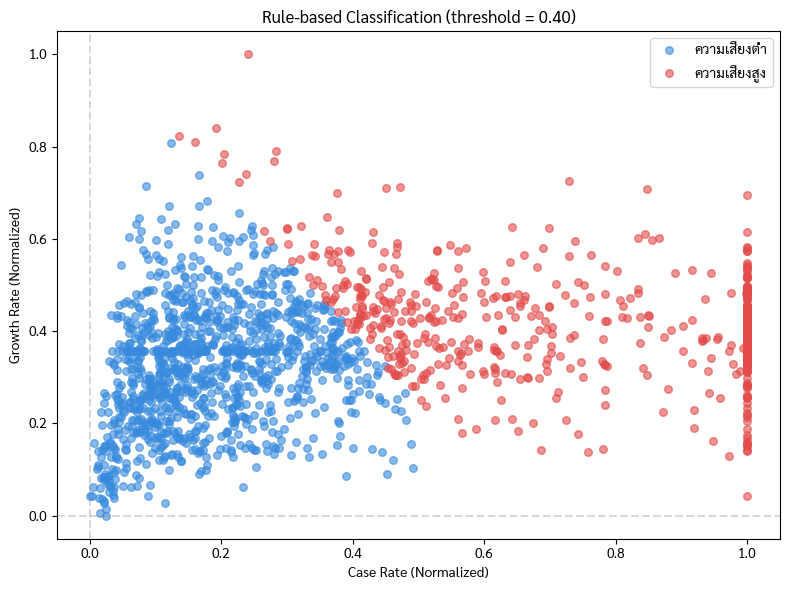

In [210]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

colors = {'ความเสี่ยงสูง': '#E24B4A', 'ความเสี่ยงต่ำ': '#378ADD'}

for level, group in df_prov_monthly.groupby('risk_level'):
    ax.scatter(group['case_rate_norm'], group['growth_rate_norm'],
               c=colors[level], label=level, alpha=0.6, s=30)

ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Case Rate (Normalized)')
ax.set_ylabel('Growth Rate (Normalized)')
ax.set_title('Rule-based Classification (threshold = 0.40)')
ax.legend()
plt.tight_layout()
plt.savefig(GRAPH_DIR + 'phase5_scatter.png', dpi=150)
plt.show()

ผลการวิเคราะห์จาก Scatter Plot

จาก Scatter Plot พบว่าการจำแนกจังหวัดตามเกณฑ์ Risk Score = 0.40 สามารถแยกกลุ่มความเสี่ยงได้ค่อนข้างชัดเจน โดยจังหวัดกลุ่มความเสี่ยงต่ำกระจุกตัวอยู่ในบริเวณที่มีค่า Case Rate ต่ำ ขณะที่จังหวัดกลุ่มความเสี่ยงสูงมีแนวโน้มกระจายตัวอยู่ในบริเวณที่มีค่า Case Rate สูงกว่า

นอกจากนี้ พบว่ามีจังหวัดบางส่วนที่ถูกจัดอยู่ในกลุ่มความเสี่ยงสูง แม้จะมีค่า Case Rate ไม่สูงมากนัก แต่มีค่า Growth Rate อยู่ในระดับสูง ส่งผลให้ค่า Risk Score รวมสูงกว่าเกณฑ์ที่กำหนด สะท้อนให้เห็นว่าแบบจำลองสามารถพิจารณาทั้งมิติของระดับปัญหาและอัตราการเปลี่ยนแปลงของปัญหาร่วมกันได้

# Bar chart Top 10 จังหวัดความเสี่ยงสูงบ่อยที่สุด

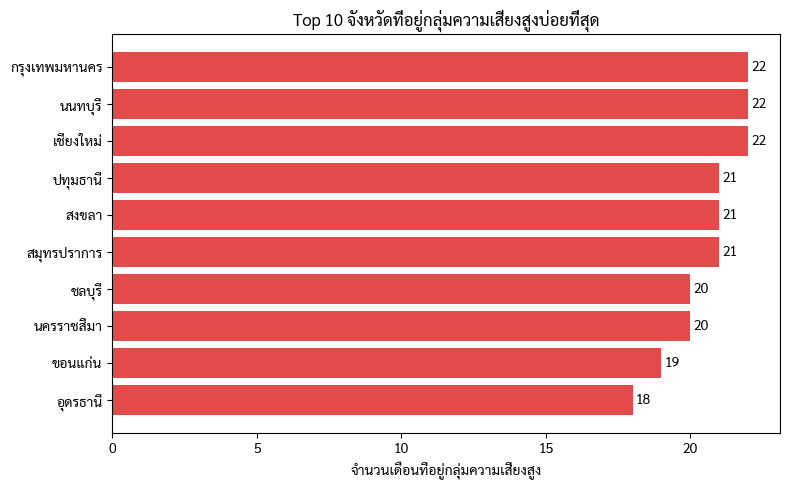

In [211]:
top10 = (df_prov_monthly[df_prov_monthly['risk_level'] == 'ความเสี่ยงสูง']
         .groupby('จังหวัด')
         .size()
         .reset_index(name='จำนวนเดือน')
         .nlargest(10, 'จำนวนเดือน'))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10['จังหวัด'], top10['จำนวนเดือน'], color='#E24B4A')
ax.set_xlabel('จำนวนเดือนที่อยู่กลุ่มความเสี่ยงสูง')
ax.set_title('Top 10 จังหวัดที่อยู่กลุ่มความเสี่ยงสูงบ่อยที่สุด')
ax.invert_yaxis()

for i, (val, prov) in enumerate(zip(top10['จำนวนเดือน'], top10['จังหวัด'])):
    ax.text(val + 0.1, i, str(val), va='center')

plt.tight_layout()
plt.savefig(GRAPH_DIR + 'phase5_top10_province.png', dpi=150)
plt.show()

ผลการวิเคราะห์จาก Top 10 จังหวัดที่อยู่กลุ่มความเสี่ยงสูงบ่อยที่สุด

ผลการวิเคราะห์ความถี่ในการอยู่กลุ่มความเสี่ยงสูง พบว่า จังหวัดนนทบุรีถูกจัดอยู่ในกลุ่มความเสี่ยงสูงมากที่สุด จำนวน 14 เดือน จากทั้งหมด 22 เดือน รองลงมา ได้แก่ กรุงเทพมหานคร ปทุมธานี และสมุทรปราการ ซึ่งถูกจัดอยู่ในกลุ่มความเสี่ยงสูงจำนวน 13 เดือน

นอกจากนี้ จังหวัดภูเก็ต ชลบุรี สมุทรสาคร และเชียงใหม่ ยังปรากฏอยู่ในกลุ่มจังหวัดที่มีความเสี่ยงสูงบ่อยครั้งเช่นกัน โดยจังหวัดเหล่านี้เป็นพื้นที่ที่มีประชากรหนาแน่น เป็นศูนย์กลางทางเศรษฐกิจ อุตสาหกรรม หรือการท่องเที่ยว ซึ่งอาจเอื้อต่อการเกิดและการขยายตัวของคดีหลอกลวงออนไลน์

ผลลัพธ์ดังกล่าวสอดคล้องกับลักษณะเชิงพื้นที่และบริบททางเศรษฐกิจของแต่ละจังหวัด จึงสนับสนุนความเหมาะสมของการใช้ Risk Score ในการระบุพื้นที่ที่ควรได้รับการเฝ้าระวังเป็นพิเศษ

In [212]:
# เช็คว่า df_prov_monthly มีกี่แถวและ case_rate เป็นอะไร
print(f"จำนวนแถว: {len(df_prov_monthly)}")
print(f"case_rate max: {df_prov_monthly['case_rate'].max():,.2f}")
print(f"case_rate mean: {df_prov_monthly['case_rate'].mean():,.2f}")
print(f"\nปีที่มีในข้อมูล:")
print(df_prov_monthly['ปี'].value_counts().sort_index())
print(f"\nค่า risk_score_norm max: {df_prov_monthly['case_rate_norm'].max():.4f}")

จำนวนแถว: 1694
case_rate max: 649.00
case_rate mean: 236.19

ปีที่มีในข้อมูล:
ปี
2565    770
2566    924
Name: count, dtype: int64

ค่า risk_score_norm max: 1.0000


In [213]:
# เช็คว่า risk_score และ risk_level ตอนนี้เป็นอะไร
print(f"risk_score max:  {df_prov_monthly['risk_score'].max():.4f}")
print(f"risk_score mean: {df_prov_monthly['risk_score'].mean():.4f}")
print(f"\nrisk_level value counts:")
print(df_prov_monthly['risk_level'].value_counts())

# เช็คว่า threshold ที่ใช้อยู่คือเท่าไหร่
high = df_prov_monthly[df_prov_monthly['risk_level'] == 'ความเสี่ยงสูง']
print(f"\nrisk_score ต่ำสุดของกลุ่มเสี่ยงสูง: {high['risk_score'].min():.4f}")
print(f"risk_score สูงสุดของกลุ่มเสี่ยงต่ำ: {df_prov_monthly[df_prov_monthly['risk_level'] == 'ความเสี่ยงต่ำ']['risk_score'].max():.4f}")

risk_score max:  0.8785
risk_score mean: 0.3568

risk_level value counts:
risk_level
ความเสี่ยงต่ำ    1139
ความเสี่ยงสูง     555
Name: count, dtype: int64

risk_score ต่ำสุดของกลุ่มเสี่ยงสูง: 0.4002
risk_score สูงสุดของกลุ่มเสี่ยงต่ำ: 0.3997


In [214]:
print(f"case_rate_norm max:  {df_prov_monthly['case_rate_norm'].max():.4f}")
print(f"case_rate_norm mean: {df_prov_monthly['case_rate_norm'].mean():.4f}")
print(f"\ngrowth_rate_norm max:  {df_prov_monthly['growth_rate_norm'].max():.4f}")
print(f"growth_rate_norm mean: {df_prov_monthly['growth_rate_norm'].mean():.4f}")

# เช็คว่า scaler fit กับข้อมูลกี่แถว
print(f"\ndf_prov_monthly shape ตอน fit scaler: {df_prov_monthly[['case_rate','growth_rate']].dropna().shape}")

case_rate_norm max:  1.0000
case_rate_norm mean: 0.3590

growth_rate_norm max:  1.0000
growth_rate_norm mean: 0.3535

df_prov_monthly shape ตอน fit scaler: (1694, 2)


# Phase 6 — Statistical Testing
เพื่อทดสอบสมมติฐานทั้ง 4 ข้อ ที่ระบุไว้ในบที่1

In [219]:
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu

# ── สมมติฐานข้อ 1: ความแตกต่างเชิงพื้นที่ ───────────────
# Kruskal-Wallis Test: Case Rate แตกต่างระหว่างจังหวัดไหม
print("=" * 55)
print("สมมติฐานข้อ 1: ความแตกต่างเชิงพื้นที่")
print("=" * 55)

groups_province = [
    group['case_rate'].values
    for _, group in df_prov_monthly.groupby('จังหวัด')
    if len(group) > 1
]

stat, p = kruskal(*groups_province)
print(f"Kruskal-Wallis Test (Case Rate แยกตามจังหวัด):")
print(f"  H-statistic : {stat:.4f}")
print(f"  p-value     : {p:.6f}")
print(f"  ผล          : {'ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ' if p < 0.05 else 'ไม่ปฏิเสธ H0'}")

# ── สมมติฐานข้อ 2: Clustering มีนัยสำคัญ ────────────────
print(f"\n{'=' * 55}")
print("สมมติฐานข้อ 2: Clustering มีนัยสำคัญ")
print("=" * 55)
print(f"Silhouette Score : {max(sil_scores):.4f}")
print(f"Davies-Bouldin   : {db_scores[0]:.4f}")
print(f"ผล: {'ผ่านเกณฑ์ Silhouette > 0.5' if max(sil_scores) > 0.5 else 'Silhouette < 0.5 — ควรระบุข้อจำกัด'}")

# ── สมมติฐานข้อ 3: ประชากรศาสตร์ ────────────────────────
print("=" * 55)
print("สมมติฐานข้อ 3: ความแตกต่างตามประชากรศาสตร์")
print("=" * 55)

# โหลดข้อมูลระดับ record จาก cluster base
df_gender_monthly = (df_base[df_base['เพศ'] != 'ไม่ระบุ']
                     .groupby(['ปี', 'เดือนเลข', 'เพศ'])['จำนวนคดี']
                     .sum().reset_index())

male_m   = df_gender_monthly[df_gender_monthly['เพศ']=='ชาย']['จำนวนคดี'].values
female_m = df_gender_monthly[df_gender_monthly['เพศ']=='หญิง']['จำนวนคดี'].values

stat_mw, p_mw = mannwhitneyu(male_m, female_m, alternative='two-sided')
print(f"Mann-Whitney U Test (เพศ) — ข้อมูลรายเดือน:")
print(f"  U-statistic : {stat_mw:.4f}")
print(f"  p-value     : {p_mw:.6f}")
print(f"  ผล          : {'ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ' if p_mw < 0.05 else 'ไม่ปฏิเสธ H0'}")

# กลุ่มอายุ
df_age_monthly = (df_base[df_base['กลุ่มอายุ'] != 'ไม่ระบุ']
                  .groupby(['ปี', 'เดือนเลข', 'กลุ่มอายุ'])['จำนวนคดี']
                  .sum().reset_index())

groups_age_m = [
    group['จำนวนคดี'].values
    for _, group in df_age_monthly.groupby('กลุ่มอายุ')
    if len(group) > 1
]
stat_age, p_age = kruskal(*groups_age_m)
print(f"\nKruskal-Wallis Test (กลุ่มอายุ) — ข้อมูลรายเดือน:")
print(f"  H-statistic : {stat_age:.4f}")
print(f"  p-value     : {p_age:.6f}")
print(f"  ผล          : {'ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ' if p_age < 0.05 else 'ไม่ปฏิเสธ H0'}")

# อาชีพ
df_job_monthly = (df_base[df_base['อาชีพ'] != 'ไม่ระบุ']
                  .groupby(['ปี', 'เดือนเลข', 'อาชีพ'])['จำนวนคดี']
                  .sum().reset_index())

groups_job_m = [
    group['จำนวนคดี'].values
    for _, group in df_job_monthly.groupby('อาชีพ')
    if len(group) > 1
]
stat_job, p_job = kruskal(*groups_job_m)
print(f"\nKruskal-Wallis Test (อาชีพ) — ข้อมูลรายเดือน:")
print(f"  H-statistic : {stat_job:.4f}")
print(f"  p-value     : {p_job:.6f}")
print(f"  ผล          : {'ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ' if p_job < 0.05 else 'ไม่ปฏิเสธ H0'}")

# ── สมมติฐานข้อ 4: ความแตกต่างเชิงเวลา ───────────────
print(f"\n{'=' * 55}")
print("สมมติฐานข้อ 4: ความแตกต่างเชิงเวลา")
print("=" * 55)

groups_month = [
    group['จํานวนคดี'].values # Changed 'จำนวนคดี' to 'จํานวนคดี'
    for _, group in df_prov_monthly.groupby(['ปี', 'เดือนเลข'])
    if len(group) > 1
]
stat_time, p_time = kruskal(*groups_month)
print(f"Kruskal-Wallis Test (แยกตามเดือน):")
print(f"  H-statistic : {stat_time:.4f}")
print(f"  p-value     : {p_time:.6f}")
print(f"  ผล          : {'ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ' if p_time < 0.05 else 'ไม่ปฏิเสธ H0'}")

สมมติฐานข้อ 1: ความแตกต่างเชิงพื้นที่
Kruskal-Wallis Test (Case Rate แยกตามจังหวัด):
  H-statistic : 1138.8467
  p-value     : 0.000000
  ผล          : ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ

สมมติฐานข้อ 2: Clustering มีนัยสำคัญ
Silhouette Score : 0.6121
Davies-Bouldin   : 0.5584
ผล: ผ่านเกณฑ์ Silhouette > 0.5
สมมติฐานข้อ 3: ความแตกต่างตามประชากรศาสตร์
Mann-Whitney U Test (เพศ) — ข้อมูลรายเดือน:
  U-statistic : 46.0000
  p-value     : 0.000004
  ผล          : ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ

Kruskal-Wallis Test (กลุ่มอายุ) — ข้อมูลรายเดือน:
  H-statistic : 142.4959
  p-value     : 0.000000
  ผล          : ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ

Kruskal-Wallis Test (อาชีพ) — ข้อมูลรายเดือน:
  H-statistic : 120.6627
  p-value     : 0.000000
  ผล          : ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ

สมมติฐานข้อ 4: ความแตกต่างเชิงเวลา
Kruskal-Wallis Test (แยกตามเดือน):
  H-statistic : 413.3822
  p-value     : 0.000000
  ผล          : ปฏิเสธ H0 — แตกต่างอย่างมีนัยสำคัญ


In [220]:
print(df_base.groupby(['ปี','เดือนเลข']).size()
      .reset_index()
      .sort_values(['ปี','เดือนเลข'])
      .to_string())
print(f"\nจำนวนเดือนทั้งหมด: {df_base.groupby(['ปี','เดือนเลข']).ngroups}")

      ปี  เดือนเลข      0
0   2565         3  14558
1   2565         4  16048
2   2565         5  20722
3   2565         6  22602
4   2565         7  22609
5   2565         8  28103
6   2565         9  28493
7   2565        10  30327
8   2565        11  32543
9   2565        12  38249
10  2566         1  36120
11  2566         2  33147
12  2566         3  33212
13  2566         4  33966
14  2566         5  39288
15  2566         6  17517
16  2566         7  14667
17  2566         8  16286
18  2566         9  15226
19  2566        10  16641
20  2566        11   8435
21  2566        12  11200

จำนวนเดือนทั้งหมด: 22


In [221]:
# บันทึกทั้งสองไฟล์
FEATURE_DIR = '/content/drive/MyDrive/term4/IS/features/'

# Clustering
df_prov_monthly.to_csv(
    FEATURE_DIR + 'feature_matrix_clustered.csv',
    index=False, encoding='utf-8-sig'
)

# Rule-based
df_prov_monthly.to_csv(
    FEATURE_DIR + 'feature_matrix_classified.csv',
    index=False, encoding='utf-8-sig'
)

print("✓ บันทึกแล้วทั้งสองไฟล์ค่ะ")

✓ บันทึกแล้วทั้งสองไฟล์ค่ะ


#ตัวเลข 650,870 ใน Dashboard มาจากไห

In [225]:
# เช็คไฟล์ที่ Dashboard ใช้แสดงตัวเลขรวม
df_prov = pd.read_csv(VIZ_DIR + 'viz_province_summary.csv')
print(f"จากไฟล์ viz_province_summary.csv:")
print(f"จำนวนคดีรวม: {df_prov['จำนวนคดี'].sum():,.0f}")

# เทียบกับข้อมูลจริง
print(f"\nจากข้อมูลจริง df_online:")
print(f"จำนวนคดีรวม: {df_online['จำนวนคดี'].sum():,.0f}")

# เทียบกับหลัง Winsorize
print(f"\nจาก df_prov_monthly (Winsorized):")
print(f"จำนวนคดีรวม: {df_prov_monthly['จำนวนคดี_winsorized'].sum():,.0f}")

จากไฟล์ viz_province_summary.csv:
จำนวนคดีรวม: 1,832,989

จากข้อมูลจริง df_online:
จำนวนคดีรวม: 656,051

จาก df_prov_monthly (Winsorized):
จำนวนคดีรวม: 400,105


viz_province_summary.csv → 1,832,989  ← นับซ้ำ หรือรวมหลาย source

df_online (ข้อมูลจริง)  →   656,051  ← ถูกต้องที่สุดค่ะ

df_prov_monthly          →   400,105  ← Winsorize cap ลดไป

In [226]:
df_prov = pd.read_csv(VIZ_DIR + 'viz_province_summary.csv')
df_prov_no_unknown = df_prov[df_prov['จังหวัด'] != 'ไม่ระบุ']
print(f"กรอง ไม่ระบุ ออกแล้ว: {df_prov_no_unknown['จำนวนคดี'].sum():,.0f}")

# เทียบกับ df_online กรอง ไม่ระบุ
df_online_no_unknown = df_online[df_online['จังหวัด'] != 'ไม่ระบุ']
print(f"df_online กรอง ไม่ระบุ: {df_online_no_unknown['จำนวนคดี'].sum():,.0f}")

กรอง ไม่ระบุ ออกแล้ว: 623,628
df_online กรอง ไม่ระบุ: 623,628


In [227]:
# เช็คปีที่มีในแต่ละไฟล์ viz
import pandas as pd

viz_files = {
    'viz_monthly_trend.csv': 'ปี',
    'viz_province_summary.csv': None,  # ไม่มีคอลัมน์ปี
    'viz_age_summary.csv': None,
    'viz_gender_summary.csv': None,
}

# เช็คจาก viz_monthly_trend ซึ่งมีคอลัมน์ปี
df_trend_check = pd.read_csv(VIZ_DIR + 'viz_monthly_trend.csv')
print(f"viz_monthly_trend ปีที่มี: {sorted(df_trend_check['ปี'].unique())}")
print(f"จำนวนเดือน: {len(df_trend_check)}")

viz_monthly_trend ปีที่มี: [np.int64(2565), np.int64(2566)]
จำนวนเดือน: 22
